# EDA: World Air Pollution and AQI (2014-2025)

**Датасет:** `train_model/data/global_air_quality_2014_2025.csv`  
**Источник:** Kaggle (World Air Pollution and AQI Dataset 2014-2025)

**Гранулярность:** наблюдения **помесячные**; минимальный шаг анализа и прогноза — календарный месяц. День в колонке `Date` — технический формат хранения.

**AQI_Bucket:** категория однозначно следует из числового AQI (0–50 Good, 51–100 Satisfactory, 101–150 Moderate, 151–200 Poor, 201–300 Very Poor, 301+ Severe). Отдельный EDA по bucket не нужен.

## Цели анализа
1. Оценить качество данных и их пригодность для моделирования.
2. Найти ключевые закономерности по загрязнителям, AQI, географии и времени.
3. Сегментировать города и построить прогноз AQI по кластерам.
4. Прогнозирование временного ряда. 

---

## План
1. Контроль качества данных (пропуски, дубли, диапазоны).
2. Распределения и взаимосвязи признаков.
3. Географические паттерны по странам/городам.
4. Кластеризация городов (**4.1** признаки, **4.2** число k, **4.3** сравнение методов).
5. Валидация и профили кластеров (**5.1** до/после, **5.2** профили).
6. Временные ряды и прогноз (**6.1** профиль, **6.2** диагностика **6.2.1–6.2.4**, **6.3** типы моделей, **6.4** отбор по MAE, **6.5** визуализация прогноза).
7. Обучение и сохранение моделей.
8. Допущения и упрощения.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy import stats

from notebook_utils import (
    build_cluster_monthly_aqi,
    cluster_balance_table,
    concise_conclusion,
    iqr_outlier_share,
    section_bar,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

DATA_PATH = '../data/global_air_quality_2014_2025.csv'
AQI_COLUMN = 'AQI'
DATE_COL = 'Date'
TARGET_COLUMNS = [
    'PM2.5 (ug/m3)',
    'PM10 (ug/m3)',
    'NO2 (ug/m3)',
    'SO2 (ug/m3)',
    'O3 (ug/m3)',
    AQI_COLUMN,
]

HOLDOUT_MONTHS = 12
HORIZON_MONTHS = 12
CV_MIN_TRAIN_MONTHS = 36  # минимум train перед первым test-блоком (expanding CV)
CV_N_FOLDS = 4  # число фолдов; веса фолдов — линейные 1:2:…:F
MODEL_CANDIDATES = [
    'SeasonalNaiveVector',
    'HoltWintersVector',
    'RidgeMultiOutput',
    'WLSRidgeMultiOutput',
    'GradientBoostingVector',
]
# Группы A/B по остаткам задаются в 6.2.4 после ARCH-теста (RESID_VARIANCE_GROUP).
PLOT_EXAMPLE_CLUSTERS = [0, 1]  # иллюстрации в 6.2.1–6.2.3, без групп A/B


In [2]:
df = pd.read_csv(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

display(df.head().T)
print('Shape:', df.shape)
print('Period:', df[DATE_COL].min(), '->', df[DATE_COL].max())
print('Countries:', df['Country'].nunique(), '| Cities:', df['City'].nunique())
print('Гранулярность: месячные наблюдения (шаг MS при агрегации).')

num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

pollutant_cols = [
    'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)',
    'NH3 (ug/m3)', 'CO (mg/m3)', 'SO2 (ug/m3)', 'O3 (ug/m3)',
    'Benzene (ug/m3)', 'Toluene (ug/m3)', 'Xylene (ug/m3)'
]

driver_cols = [
    'Wind_Speed (km/h)', 'Humidity (%)', 'Deforestation_Rate_%',
    'Industry_Growth_%', 'CO2_Emission_MT', 'Population_Density_per_SqKm'
]


,0,1,2,3,4
Country,Australia,Australia,Australia,Australia,Australia
State,Australian Capital Territory,New South Wales,New South Wales,New South Wales,New South Wales
City,Canberra,Sydney,Newcastle,Wollongong,Central Coast
Date,2014-01-01 00:00:00,2014-01-01 00:00:00,2014-01-01 00:00:00,2014-01-01 00:00:00,2014-01-01 00:00:00
PM2.5 (ug/m3),6.85,14.88,5.57,4.98,4.94
PM10 (ug/m3),21.13,8.24,18.62,19.61,9.7
NO (ug/m3),3.37,2.46,2.57,2.52,4.26
NO2 (ug/m3),7.16,7.41,5.44,7.41,12.23
NOx (ppb),10.53,9.87,8.01,9.93,16.49
NH3 (ug/m3),6.12,2.63,4.07,4.67,0.46


Shape: (331920, 24)
Period: 2014-01-01 00:00:00 -> 2025-12-01 00:00:00
Countries: 24 | Cities: 2270
Гранулярность: месячные наблюдения (шаг MS при агрегации).


## 1. Контроль качества данных

В EDA для environmental/time-series задач контроль качества особенно критичен: если есть пропуски, дубли или физически невозможные значения, модель начнет «учить ошибки измерений», а не реальные закономерности.

Проверим:
- пропуски по столбцам;
- дублирования (полные и по ключам `Country, State, City, Date`);
- диапазоны числовых признаков (наличие отрицательных концентраций и т.д.).


In [3]:
section_bar('1. Контроль качества данных')

missing = df.isna().mean().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

print('Пропуски (доля):')
display(missing_nonzero.to_frame('missing_ratio').head(20))

full_dups = df.duplicated().sum()
key_cols = ['Country', 'State', 'City', DATE_COL]
key_dups = df.duplicated(subset=key_cols).sum()

print(f'Полные дубли: {full_dups}')
print(f'Дубли по ключу {key_cols}: {key_dups}')

desc = df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
display(desc[['min', '1%', '5%', '50%', '95%', '99%', 'max']])

neg_counts = (df[num_cols] < 0).sum().sort_values(ascending=False)
neg_counts = neg_counts[neg_counts > 0]
print('Отрицательные значения в числовых признаках:')
display(neg_counts.to_frame('negative_count'))

conclusion = []
conclusion.append(f'Пропуски есть в {missing_nonzero.shape[0]} столбцах из {len(df.columns)}.')
conclusion.append(f'Полных дублей: {full_dups}, дублей по бизнес-ключу: {key_dups}.')
concise_conclusion(conclusion)



1. Контроль качества данных
Пропуски (доля):


,missing_ratio


Полные дубли: 0
Дубли по ключу ['Country', 'State', 'City', 'Date']: 0


,min,1%,5%,50%,95%,99%,max
PM2.5 (ug/m3),0.00,3.330000,6.244213,21.777052,119.800000,231.528100,800.000000
PM10 (ug/m3),0.00,6.710037,11.716591,40.043465,254.320000,466.388600,1588.180000
NO (ug/m3),0.00,1.010000,2.750000,10.288869,40.440000,70.350000,155.496505
NO2 (ug/m3),0.00,3.130000,6.560000,21.560000,73.100000,122.578100,520.506185
NOx (ppb),0.00,2.380000,6.030000,22.439907,75.430000,127.290000,325.905799
NH3 (ug/m3),0.00,0.690000,1.690000,7.418742,29.520087,50.096200,91.550000
CO (mg/m3),0.00,0.090000,0.180000,0.643352,3.150000,6.120000,15.000000
SO2 (ug/m3),0.00,0.620000,1.510000,6.160000,33.420000,72.970000,1500.000000
O3 (ug/m3),0.00,10.000000,17.330000,41.320000,85.570000,121.728100,200.000000
Benzene (ug/m3),0.00,0.070058,0.188520,1.010000,5.190000,9.910000,30.000000


Отрицательные значения в числовых признаках:


,negative_count
Industry_Growth_%,5430
CO2_Emission_MT,8



Краткий вывод:
- Пропуски есть в 0 столбцах из 24.
- Полных дублей: 0, дублей по бизнес-ключу: 0.


## 2. Распределения и связи признаков

Для AQI обычно важны две вещи:
1. Асимметрия и тяжелые хвосты (часто встречаются в данных о загрязнении).
2. Сила связи между отдельными загрязнителями и итоговым `AQI`.

Сначала проверим формы распределений и выбросы, затем — корреляции с целевой переменной.



2. Распределения и корреляции


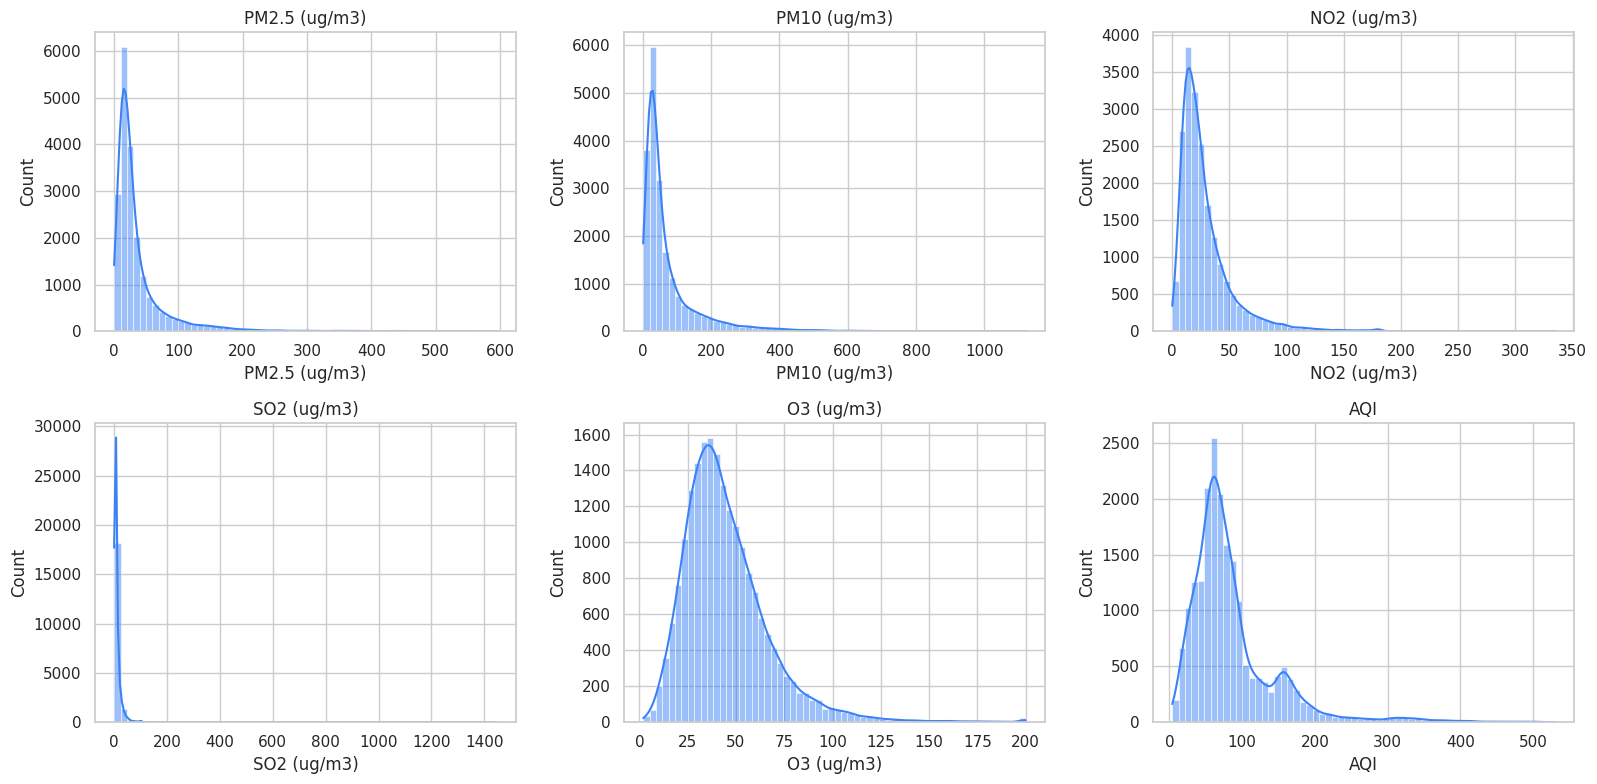

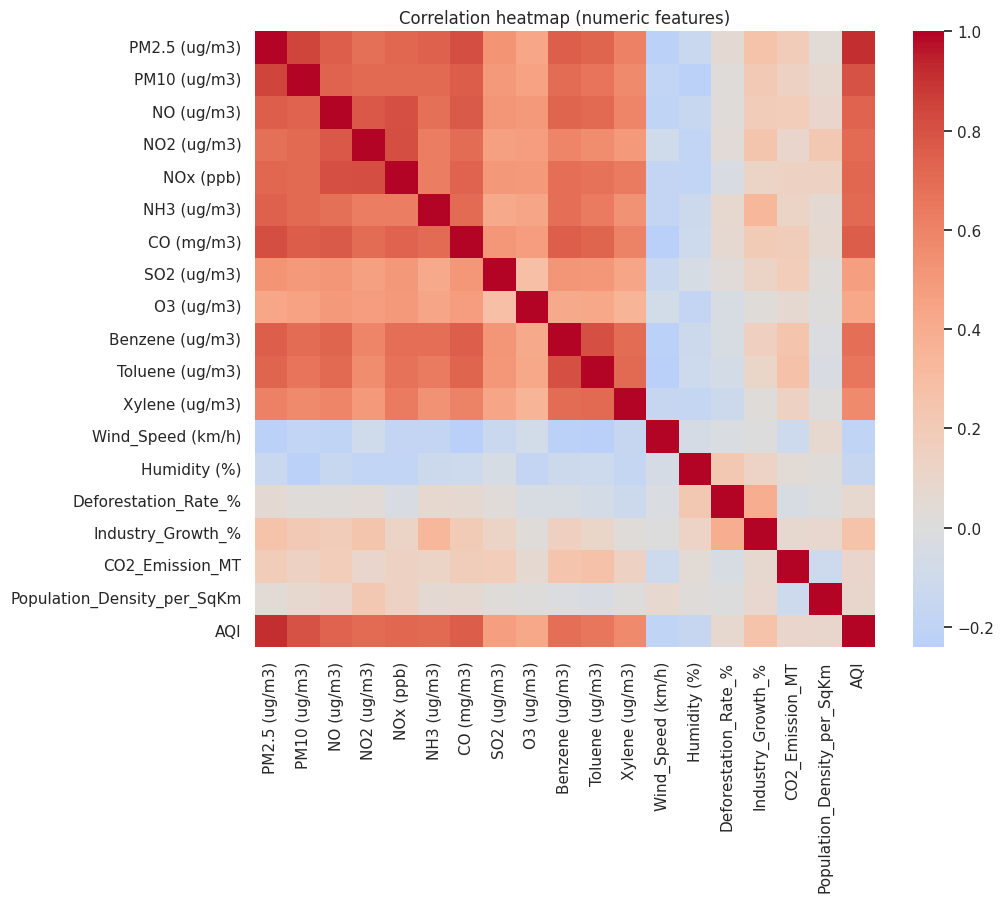

Топ корреляций с AQI (по модулю):


,corr_with_AQI
PM2.5 (ug/m3),0.913997
PM10 (ug/m3),0.799519
CO (mg/m3),0.758590
NO (ug/m3),0.734196
NOx (ppb),0.721465
NH3 (ug/m3),0.711826
NO2 (ug/m3),0.707495
Benzene (ug/m3),0.690783
Toluene (ug/m3),0.656059
Xylene (ug/m3),0.573264


Доля выбросов (IQR method):


,outlier_share
PM10 (ug/m3),0.10665
PM2.5 (ug/m3),0.10450
SO2 (ug/m3),0.09165
AQI,0.08250
NO2 (ug/m3),0.06680
O3 (ug/m3),0.03540


Нормальность по KS-тесту для TARGET_COLUMNS (p>=0.05 -> normal):


,feature,ks_stat,p_value,normality_flag,skew
0,PM2.5 (ug/m3),0.230171,0.000000e+00,non_normal,4.256354
1,PM10 (ug/m3),0.229237,0.000000e+00,non_normal,3.565692
2,NO2 (ug/m3),0.159075,0.000000e+00,non_normal,2.788639
3,SO2 (ug/m3),0.317508,0.000000e+00,non_normal,25.636079
5,AQI,0.175098,0.000000e+00,non_normal,2.391738
4,O3 (ug/m3),0.086938,5.694701e-132,non_normal,1.777383



Краткий вывод:
- AQI имеет выраженную линейную связь с целевыми 5 загрязнителями: PM2.5 (ug/m3): 0.914, PM10 (ug/m3): 0.800, NO2 (ug/m3): 0.707, SO2 (ug/m3): 0.467, O3 (ug/m3): 0.423.
- По KS-тесту большинство целевых распределений ненормальные (6 из 6), и это согласуется с асимметрией (skew).
- Практично применять лог/Box-Cox/Yeo-Johnson преобразования и робастное масштабирование (когда признаки масштабируются по медиане и межквартильному размаху, чтобы выбросы меньше искажали модель).
- AQI_Bucket — производная от числового AQI по фиксированной шкале датасета; отдельный анализ bucket не нужен.
- Для прогноза: сравнение пяти моделей на hold-out 12 мес. — раздел 6.4; метрика отбора — MAE по 6 таргетам.
- Семейства Prophet / SARIMAX / GARCH обсуждаются в 6.3 как ориентир; в таблице 6.4 — только реализованные кандидаты.


In [4]:
section_bar('2. Распределения и корреляции')

core_cols = pollutant_cols + driver_cols + [AQI_COLUMN]
core_cols = [c for c in core_cols if c in df.columns]

sample = df[core_cols].dropna().sample(min(20000, df[core_cols].dropna().shape[0]), random_state=42)

# 1) Гистограммы ключевых признаков
plot_cols = [c for c in TARGET_COLUMNS if c in sample.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, c in enumerate(plot_cols):
    sns.histplot(sample[c], bins=60, kde=True, ax=axes[i], color='#3B82F6')
    axes[i].set_title(c)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# 2) Корреляция со сводной тепловой картой
corr = sample[core_cols].corr(numeric_only=True)
top_corr = corr[AQI_COLUMN].drop(AQI_COLUMN).sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.show()

print('Топ корреляций с AQI (по модулю):')
display(top_corr.head(12).to_frame('corr_with_AQI'))

# 3) Выбросы по IQR для ключевых поллютантов
outlier_share = sample[plot_cols].apply(iqr_outlier_share).sort_values(ascending=False)
print('Доля выбросов (IQR method):')
display(outlier_share.to_frame('outlier_share'))

# 4) Тест нормальности (Kolmogorov-Smirnov) для целевых колонок
normality_rows = []
for col in [c for c in TARGET_COLUMNS if c in sample.columns]:
    s = sample[col].dropna().astype(float)
    if len(s) < 30 or np.isclose(s.std(ddof=1), 0):
        normality_rows.append(
            {
                'feature': col,
                'ks_stat': np.nan,
                'p_value': np.nan,
                'normality_flag': 'insufficient_data',
                'skew': s.skew() if len(s) > 2 else np.nan,
            }
        )
        continue

    z = (s - s.mean()) / s.std(ddof=1)
    ks_stat, p_value = stats.kstest(z, 'norm')
    normality_rows.append(
        {
            'feature': col,
            'ks_stat': float(ks_stat),
            'p_value': float(p_value),
            'normality_flag': 'normal' if p_value >= 0.05 else 'non_normal',
            'skew': float(s.skew()),
        }
    )

normality_df = pd.DataFrame(normality_rows).sort_values('p_value', na_position='last')
print('Нормальность по KS-тесту для TARGET_COLUMNS (p>=0.05 -> normal):')
display(normality_df)

conclusion = []
if not top_corr.empty:
    target5 = [c for c in TARGET_COLUMNS if c not in {AQI_COLUMN} and c in top_corr.index]
    top_target5 = top_corr.loc[target5].sort_values(key=np.abs, ascending=False).head(5)
    if not top_target5.empty:
        strongest = ', '.join([f"{idx}: {val:.3f}" for idx, val in top_target5.items()])
        conclusion.append(f'AQI имеет выраженную линейную связь с целевыми 5 загрязнителями: {strongest}.')

non_normal_count = int((normality_df['normality_flag'] == 'non_normal').sum()) if not normality_df.empty else 0
conclusion.append(
    f'По KS-тесту большинство целевых распределений ненормальные ({non_normal_count} из {len(normality_df)}), '
    'и это согласуется с асимметрией (skew).'
)
conclusion.append(
    'Практично применять лог/Box-Cox/Yeo-Johnson преобразования и робастное масштабирование '
    '(когда признаки масштабируются по медиане и межквартильному размаху, чтобы выбросы меньше искажали модель).'
)
conclusion.append(
    'AQI_Bucket — производная от числового AQI по фиксированной шкале датасета; отдельный анализ bucket не нужен.'
)
conclusion.append(
    'Для прогноза: сравнение пяти моделей на hold-out 12 мес. — раздел 6.4; метрика отбора — MAE по 6 таргетам.'
)
conclusion.append(
    'Семейства Prophet / SARIMAX / GARCH обсуждаются в 6.3 как ориентир; в таблице 6.4 — только реализованные кандидаты.'
)
concise_conclusion(conclusion)


## 3. Географические паттерны

В разделе 2 мы увидели асимметричные и ненормальные распределения по `TARGET_COLUMNS` и сильную связь `AQI` с 5 целевыми загрязнителями. Теперь проверяем, насколько эти эффекты различаются географически:
- где стабильно высокие уровни загрязнения;
- где максимальная вариативность (`std`) по AQI;
- насколько выражена межстрановая и межгородская неоднородность.



3. Географические паттерны


,mean,median,std,count
Country,,,,
Pakistan,187.183984,173.0,75.712880,11376
Bangladesh,183.989675,165.0,90.219561,10944
India,140.105915,93.0,112.456339,20592
Nigeria,126.319155,122.0,61.431084,10368
Egypt,120.847353,125.0,37.619119,15264
Indonesia,90.765588,79.0,53.515968,13536
Mexico,87.760969,79.0,36.707407,12672
Turkey,86.454486,81.0,31.217338,10656
China,83.359205,72.0,51.097286,22032


mean  median         std  count
Country       City                                              
India         Udaipur      133.892361    78.0  119.047609    288
South Korea   Gwangju       95.791667    90.0   33.853214    288
United States Aurora        64.173611    63.0   17.690065    288
              Columbus      62.583333    62.5   13.909363    288
              Springfield   55.409722    57.0   16.487813    432
              Rochester     52.246528    54.0   15.405494    288
              Kansas City   50.187500    53.0   13.583382    288
              Columbia      49.833333    53.0   14.636121    288
Germany       Erfurt        47.197917    51.0   15.074001    288
              Kiel          46.482639    49.0   15.058297    288
United States Newark        44.795139    42.0   21.857068    288
              Bellevue      44.510417    39.0   24.994213    288
              Charleston    43.916667    45.0   17.140128    288
              Portland      41.458333    38.0   21.526703    288

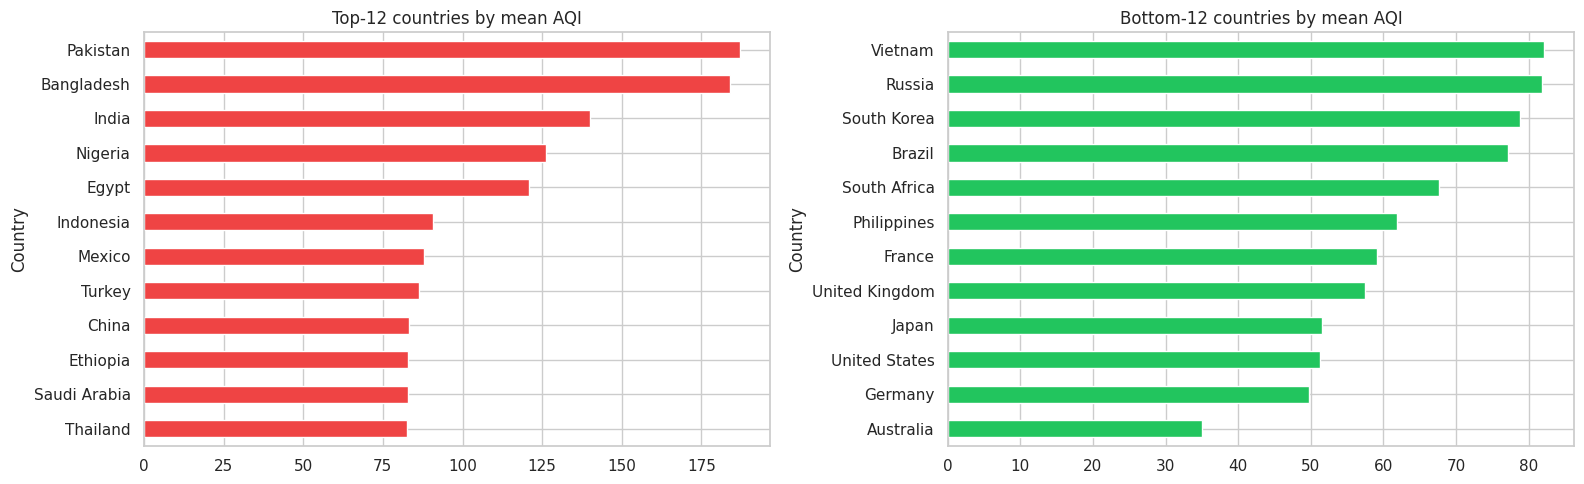


Краткий вывод:
- Данные неоднородны: от Australia (лучше) до Pakistan (хуже) по среднему AQI.
- Логичный следующий шаг — сегментирование/кластеризация городов и стран по похожим профилям загрязнения и динамики AQI.
- География и климат важны, но это только часть картины; кластеры лучше строить по совокупности факторов: уровни ключевых загрязнителей, их динамика во времени и фоновые условия среды/развития территории.


In [5]:
section_bar('3. Географические паттерны')

country_stats = (
    df.groupby('Country')[AQI_COLUMN]
      .agg(['mean', 'median', 'std', 'count'])
      .sort_values('mean', ascending=False)
)

city_stats = (
    df.groupby(['Country', 'City'])[AQI_COLUMN]
      .agg(['mean', 'median', 'std', 'count'])
      .query('count >= 200')
      .sort_values('mean', ascending=False)
)

display(country_stats.head(15))
display(city_stats.head(20))

# Top/Bottom countries by mean AQI (с минимальной репрезентативностью)
min_obs_country = 365
country_filtered = country_stats[country_stats['count'] >= min_obs_country]

top_k = min(12, country_filtered.shape[0])
if top_k > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    country_filtered.head(top_k)['mean'].sort_values().plot(kind='barh', ax=axes[0], color='#EF4444')
    axes[0].set_title(f'Top-{top_k} countries by mean AQI')

    country_filtered.tail(top_k)['mean'].sort_values().plot(kind='barh', ax=axes[1], color='#22C55E')
    axes[1].set_title(f'Bottom-{top_k} countries by mean AQI')
    plt.tight_layout()
    plt.show()

conclusion = []
if not country_filtered.empty:
    worst_country = country_filtered['mean'].idxmax()
    best_country = country_filtered['mean'].idxmin()
    conclusion.append(f'Данные неоднородны: от {best_country} (лучше) до {worst_country} (хуже) по среднему AQI.')
conclusion.append('Логичный следующий шаг — сегментирование/кластеризация городов и стран по похожим профилям загрязнения и динамики AQI.')
conclusion.append('География и климат важны, но это только часть картины; кластеры лучше строить по совокупности факторов: уровни ключевых загрязнителей, их динамика во времени и фоновые условия среды/развития территории.')
concise_conclusion(conclusion)


## 4. Кластеризация городов

Задача: сегментировать города на устойчивые группы по экологическому профилю, чтобы использовать `cluster_id` как внутренний routing-ключ для моделей прогнозирования.

Пайплайн:
1. Подготовить city-level признаки для кластеризации.
2. Нормализовать признаки и сжать их через **KernelPCA** (число компонент — вручную по графику собственных значений).
3. Определить оптимальное число кластеров (`elbow + silhouette`).
4. Сравнить несколько методов кластеризации.
5. Сохранить лучший вариант и профилировать кластеры.



4.1. Признаки для кластеризации


,0,1,2,3,4
Country,Australia,Australia,Australia,Australia,Australia
State,Australian Capital Territory,New South Wales,New South Wales,New South Wales,New South Wales
City,Canberra,Albury,Bathurst,Central Coast,Coffs Harbour
PM2.5 (ug/m3)__mean,7.746875,7.490417,7.470208,8.009722,7.900486
PM2.5 (ug/m3)__std,5.465279,2.815332,3.028767,4.871349,4.855085
PM10 (ug/m3)__mean,16.631875,14.696042,13.922639,15.680486,15.186458
PM10 (ug/m3)__std,10.029198,6.253688,4.959814,7.947403,7.210376
NO2 (ug/m3)__mean,10.947569,11.115417,10.673125,11.146319,10.454375
NO2 (ug/m3)__std,3.536053,3.262238,3.685518,3.322589,3.477202
SO2 (ug/m3)__mean,1.948889,1.904861,1.971875,1.981042,2.007361


City profiles shape: (2305, 22)
Features used: 19


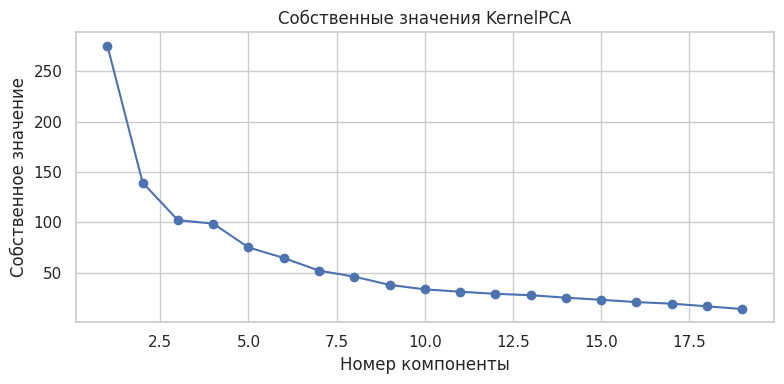

Было признаков: 19
По графику выберите число компонент и задайте N_KERNEL_PCA_COMPONENTS ниже.
Для понижения размерности используем 3 компонент KernelPCA (kernel=rbf, gamma=0.06).
Стало признаков после KernelPCA: 3

Краткий вывод:
- Сформирован city-level датасет из 2305 городов с 19 исходными признаками.
- Для кластеризации используется KernelPCA с 3 компонентами (выбор по графику собственных значений).
- Нелинейное сжатие признаков обычно делает DBSCAN устойчивее к шуму, чем кластеризация в исходном пространстве.


In [6]:
section_bar('4.1. Признаки для кластеризации')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import KernelPCA

_src = Path('../src').resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
import cluster_forecast as cf

# Из загрязнителей берем целевые без AQI, но остальные полезные признаки сохраняем
cluster_pollutants = [c for c in TARGET_COLUMNS if c != AQI_COLUMN and c in df.columns]

cluster_drivers = [
    'Wind_Speed (km/h)', 'Humidity (%)', 'Deforestation_Rate_%',
    'Industry_Growth_%', 'CO2_Emission_MT', 'Population_Density_per_SqKm'
]
cluster_drivers = [c for c in cluster_drivers if c in df.columns]

city_group_cols = ['Country', 'State', 'City']

# Агрегаты: 5 поллютантов + AQI + driver-признаки
agg_dict = {c: ['mean', 'std'] for c in (cluster_pollutants + [AQI_COLUMN])}
agg_dict.update({c: ['mean'] for c in cluster_drivers})

city_profile = (
    df.groupby(city_group_cols)
      .agg(agg_dict)
)

city_profile.columns = ['__'.join(col).strip('_') for col in city_profile.columns]
city_profile = city_profile.reset_index()

# Динамическая фича по AQI

def trend_slope(group):
    g = group.sort_values(DATE_COL)
    y = g[AQI_COLUMN].astype(float).values
    x = np.arange(len(y), dtype=float)
    if len(y) < 2 or np.allclose(y.std(), 0):
        return 0.0
    return float(np.polyfit(x, y, 1)[0])

slopes = (
    df.groupby(city_group_cols)
      .apply(trend_slope)
      .reset_index(name='AQI_trend_slope')
)

city_profile = city_profile.merge(slopes, on=city_group_cols, how='left')

feature_cols = [c for c in city_profile.columns if c not in city_group_cols]

# Импутация на случай NaN в std и т.д.
city_profile[feature_cols] = city_profile[feature_cols].replace([np.inf, -np.inf], np.nan)
city_profile[feature_cols] = city_profile[feature_cols].fillna(city_profile[feature_cols].median())

display(city_profile.head().T)
print('City profiles shape:', city_profile.shape)
print('Features used:', len(feature_cols))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(city_profile[feature_cols])

# KernelPCA для кластеризации (число компонент — вручную по графику собственных значений)
KERNEL = 'rbf'
GAMMA = 0.06

max_components = min(X_scaled.shape[0] - 1, X_scaled.shape[1])
kpca_full = KernelPCA(
    n_components=max_components,
    kernel=KERNEL,
    gamma=GAMMA,
    n_jobs=-1,
    random_state=42,
    eigen_solver='dense',
)
kpca_full.fit(X_scaled)

ev = kpca_full.eigenvalues_
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(ev) + 1), ev, 'bo-')
plt.title('Собственные значения KernelPCA')
plt.xlabel('Номер компоненты')
plt.ylabel('Собственное значение')
plt.tight_layout()
plt.show()

print(f'Было признаков: {X_scaled.shape[1]}')
print('По графику выберите число компонент и задайте N_KERNEL_PCA_COMPONENTS ниже.')

# Задайте вручную после просмотра графика (как в clustering_clients.ipynb)
N_KERNEL_PCA_COMPONENTS = 3

kpca_model = KernelPCA(
    n_components=N_KERNEL_PCA_COMPONENTS,
    kernel=KERNEL,
    gamma=GAMMA,
    n_jobs=-1,
    random_state=42,
    eigen_solver='dense',
)
X_cluster = kpca_model.fit_transform(X_scaled)

print(
    f'Для понижения размерности используем {N_KERNEL_PCA_COMPONENTS} компонент KernelPCA '
    f'(kernel={KERNEL}, gamma={GAMMA}).'
)
print(f'Стало признаков после KernelPCA: {X_cluster.shape[1]}')

concise_conclusion([
    f'Сформирован city-level датасет из {city_profile.shape[0]} городов с {len(feature_cols)} исходными признаками.',
    f'Для кластеризации используется KernelPCA с {N_KERNEL_PCA_COMPONENTS} компонентами (выбор по графику собственных значений).',
    'Нелинейное сжатие признаков обычно делает DBSCAN устойчивее к шуму, чем кластеризация в исходном пространстве.'
])



4.2. Число кластеров (elbow + silhouette)


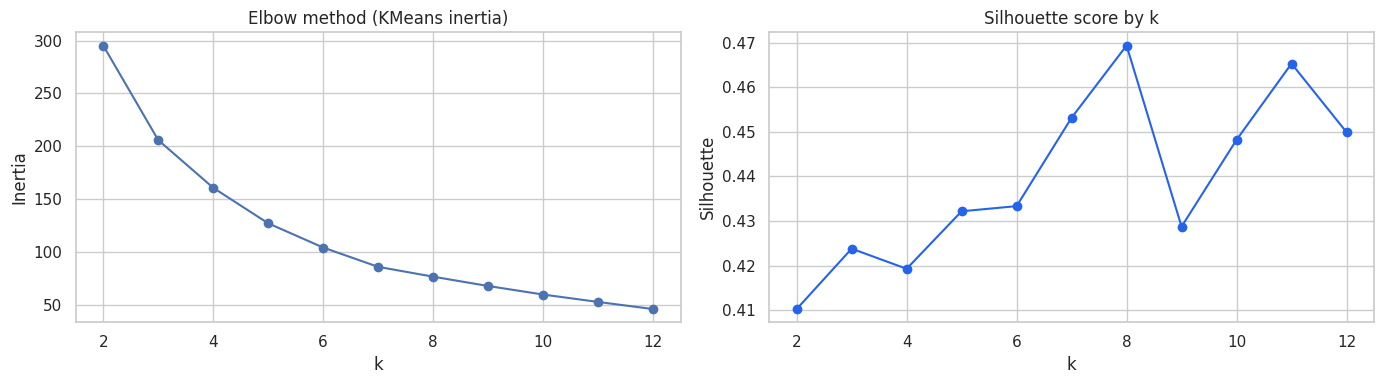

Best k by silhouette: 8

Краткий вывод:
- По silhouette оптимальный k в первом приближении: 8.
- Elbow-график используется как sanity-check, чтобы не брать избыточное число сегментов.
- Итоговый k дополнительно проверяем сравнением разных алгоритмов кластеризации.


In [7]:
section_bar('4.2. Число кластеров (elbow + silhouette)')

k_values = list(range(2, 13))
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title('Elbow method (KMeans inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_values, sil_scores, marker='o', color='#2563EB')
axes[1].set_title('Silhouette score by k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(sil_scores))]
print('Best k by silhouette:', best_k)

concise_conclusion([
    f'По silhouette оптимальный k в первом приближении: {best_k}.',
    'Elbow-график используется как sanity-check, чтобы не брать избыточное число сегментов.',
    'Итоговый k дополнительно проверяем сравнением разных алгоритмов кластеризации.'
])


In [8]:
section_bar('4.3. Сравнение методов кластеризации')

method_results = []
labels_store = {}

# KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_kmeans = kmeans.fit_predict(X_cluster)
score_kmeans = silhouette_score(X_cluster, labels_kmeans)
method_results.append({'method': f'KMeans(k={best_k})', 'silhouette': score_kmeans, 'n_clusters': len(np.unique(labels_kmeans))})
labels_store['KMeans'] = labels_kmeans

# Agglomerative
agg = AgglomerativeClustering(n_clusters=best_k)
labels_agg = agg.fit_predict(X_cluster)
score_agg = silhouette_score(X_cluster, labels_agg)
method_results.append({'method': f'Agglomerative(k={best_k})', 'silhouette': score_agg, 'n_clusters': len(np.unique(labels_agg))})
labels_store['Agglomerative'] = labels_agg

# DBSCAN grid-search в KernelPCA-пространстве
# Важно: при слишком большом eps все точки попадают в 1 кластер -> silhouette = NaN
eps_grid = [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25, 0.3]

min_samples_grid = [3, 5, 8, 10, 15, 20, 30]
max_noise_ratio = 0.10  # жесткое ограничение по шуму
min_required_clusters = 3  # минимум кластеров по условию

dbscan_rows = []
best_dbscan = None

for eps in eps_grid:
    for min_s in min_samples_grid:
        db = DBSCAN(eps=eps, min_samples=min_s, metric='euclidean')
        labels = db.fit_predict(X_cluster)

        noise_size = int((labels == -1).sum())
        noise_ratio = noise_size / len(labels)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        valid_mask = labels != -1
        if valid_mask.sum() > min_s and n_clusters > 1:
            sil = float(silhouette_score(X_cluster[valid_mask], labels[valid_mask]))
        else:
            sil = np.nan

        row = {
            'eps': eps,
            'min_samples': min_s,
            'silhouette': sil,
            'n_clusters': int(n_clusters),
            'noise_size': noise_size,
            'noise_ratio': noise_ratio,
        }
        dbscan_rows.append(row)

        is_valid = (not np.isnan(sil)) and (n_clusters >= min_required_clusters) and (noise_ratio <= max_noise_ratio)
        if is_valid:
            if best_dbscan is None:
                best_dbscan = (row, labels)
            else:
                best_row, _ = best_dbscan
                better_sil = sil > best_row['silhouette']
                tie_break = np.isclose(sil, best_row['silhouette']) and noise_size < best_row['noise_size']
                if better_sil or tie_break:
                    best_dbscan = (row, labels)

dbscan_grid_df = pd.DataFrame(dbscan_rows).sort_values(
    ['silhouette', 'n_clusters', 'noise_size'],
    ascending=[False, False, True],
    na_position='last'
)

print('DBSCAN grid-search results (KernelPCA space):')
display(dbscan_grid_df.head(30))

valid_configs = dbscan_grid_df[
    dbscan_grid_df['silhouette'].notna()
    & (dbscan_grid_df['n_clusters'] >= min_required_clusters)
    & (dbscan_grid_df['noise_ratio'] <= max_noise_ratio)
]
print(
    f"Валидных конфигураций (n_clusters>={min_required_clusters}, "
    f"noise_ratio<={max_noise_ratio}, silhouette not NaN): {len(valid_configs)}"
)
if len(valid_configs) > 0:
    print('Лучший валидный кандидат по текущим ограничениям:')
    display(valid_configs.head(1))

if best_dbscan is not None:
    best_row, labels_db = best_dbscan
    method_results.append({
        'method': f"DBSCAN(eps={best_row['eps']},min_samples={best_row['min_samples']})",
        'silhouette': best_row['silhouette'],
        'n_clusters': best_row['n_clusters']
    })
    labels_store['DBSCAN'] = labels_db
else:
    print(
        'DBSCAN: не найден валидный конфиг при ограничениях '
        f'n_clusters>={min_required_clusters} и noise_ratio<={max_noise_ratio}. '
        'Можно расширить eps-grid/min_samples или скорректировать KernelPCA параметры.'
    )
    method_results.append({'method': 'DBSCAN(grid-search)', 'silhouette': np.nan, 'n_clusters': 0})

method_df = pd.DataFrame(method_results).sort_values('silhouette', ascending=False, na_position='last')
display(method_df)

best_method = method_df.iloc[0]['method']
print('Best clustering method:', best_method)

# Финальные метки — тот же pipeline, что trainer.py (cluster_forecast.assign_city_clusters)
df, city_profile = cf.assign_city_clusters(df, city_profile, n_clusters=best_k)


print('Баланс кластеров (города и строки):')
display(cluster_balance_table(df, city_profile))

print('Cluster distribution:')
display(city_profile['cluster_id'].value_counts(dropna=False).to_frame('cities_count'))

concise_conclusion([
    f'Лучший метод по silhouette: {best_method}.',
    'Кластер сохранен в city_profile как cluster_id и добавлен в исходный df для дальнейшего моделирования.',
    'Этот cluster_id можно использовать как маршрутизация модели прогноза по cluster_id.'
])



4.3. Сравнение методов кластеризации


DBSCAN grid-search results (KernelPCA space):


,eps,min_samples,silhouette,n_clusters,noise_size,noise_ratio
20,0.020,30,0.973232,2,2172,0.942299
11,0.010,15,0.915448,2,2272,0.985683
2,0.005,8,0.891055,3,2270,0.984816
19,0.020,20,0.865885,5,2014,0.873753
18,0.020,15,0.852562,7,1926,0.835575
26,0.030,20,0.838154,10,1663,0.721475
17,0.020,10,0.813410,14,1740,0.754881
27,0.030,30,0.811886,6,1877,0.814317
1,0.005,5,0.779366,7,2238,0.970933
16,0.020,8,0.730531,22,1614,0.700217


Валидных конфигураций (n_clusters>=3, noise_ratio<=0.1, silhouette not NaN): 13
Лучший валидный кандидат по текущим ограничениям:


,eps,min_samples,silhouette,n_clusters,noise_size,noise_ratio
47,0.1,20,0.386983,8,198,0.0859


...

Best clustering method: KMeans(k=8)
Баланс кластеров (города и строки):


,n_cities,n_rows,share_rows
cluster_id,,,
0,288,41472,0.1249
1,458,65952,0.1987
2,640,92160,0.2777
3,146,21024,0.0633
4,125,18000,0.0542
5,324,46656,0.1406
6,197,28368,0.0855
7,127,18288,0.0551


Cluster distribution:


,cities_count
cluster_id,
2,640
1,458
5,324
0,288
6,197
3,146
7,127
4,125



Краткий вывод:
- Лучший метод по silhouette: KMeans(k=8).
- Кластер сохранен в city_profile как cluster_id и добавлен в исходный df для дальнейшего моделирования.
- Этот cluster_id можно использовать как маршрутизация модели прогноза по cluster_id.


## 5.1. Эффект сегментации (до/после)

После кластеризации критично проверить, стали ли данные внутри сегментов более однородными:
- выросла ли нормальность распределений по целевым признакам;
- снизилась ли шумность (разброс AQI) внутри сегментов.


In [9]:
section_bar('5.1. Сегментация: до и после')

# Сравнение до/после кластеризации по нормальности и шумности
# 1) Нормальность до кластеризации (по всему датасету)
baseline_norm_rows = []
for col in [c for c in TARGET_COLUMNS if c in df.columns]:
    s = df[col].dropna().astype(float)
    if len(s) < 30 or np.isclose(s.std(ddof=1), 0):
        baseline_norm_rows.append({'feature': col, 'normality_flag': 'insufficient_data'})
        continue
    z = (s - s.mean()) / s.std(ddof=1)
    _, p_value = stats.kstest(z, 'norm')
    baseline_norm_rows.append({'feature': col, 'normality_flag': 'normal' if p_value >= 0.05 else 'non_normal'})

baseline_norm_df = pd.DataFrame(baseline_norm_rows)
baseline_normal_share = (baseline_norm_df['normality_flag'] == 'normal').mean() if not baseline_norm_df.empty else np.nan

# 2) Нормальность после кластеризации (внутри каждого кластера)
cluster_norm_rows = []
for cid, part in df.groupby('cluster_id'):
    for col in [c for c in TARGET_COLUMNS if c in part.columns]:
        s = part[col].dropna().astype(float)
        if len(s) < 30 or np.isclose(s.std(ddof=1), 0):
            cluster_norm_rows.append({'cluster_id': int(cid), 'feature': col, 'normality_flag': 'insufficient_data'})
            continue
        z = (s - s.mean()) / s.std(ddof=1)
        _, p_value = stats.kstest(z, 'norm')
        cluster_norm_rows.append({'cluster_id': int(cid), 'feature': col, 'normality_flag': 'normal' if p_value >= 0.05 else 'non_normal'})

cluster_norm_df = pd.DataFrame(cluster_norm_rows)
cluster_normal_share = (cluster_norm_df['normality_flag'] == 'normal').mean() if not cluster_norm_df.empty else np.nan

# 3) Шумность: глобальный std AQI vs взвешенный внутрикластерный std AQI
global_aqi_std = df[AQI_COLUMN].dropna().std(ddof=1)
cluster_aqi_std = df.groupby('cluster_id')[AQI_COLUMN].std(ddof=1)
cluster_sizes = df.groupby('cluster_id')[AQI_COLUMN].size()
weighted_within_std = np.average(cluster_aqi_std.fillna(0), weights=cluster_sizes) if len(cluster_aqi_std) > 0 else np.nan

comparison_df = pd.DataFrame([
    {
        'baseline_normal_share': baseline_normal_share,
        'cluster_normal_share': cluster_normal_share,
        'normality_delta': cluster_normal_share - baseline_normal_share if pd.notna(baseline_normal_share) and pd.notna(cluster_normal_share) else np.nan,
        'global_aqi_std': global_aqi_std,
        'weighted_within_cluster_aqi_std': weighted_within_std,
        'noise_reduction_ratio': weighted_within_std / global_aqi_std if pd.notna(global_aqi_std) and global_aqi_std != 0 else np.nan,
    }
])

print('Сравнение до/после кластеризации (нормальность и шумность):')
display(comparison_df)

conclusion_e = []
if pd.notna(baseline_normal_share) and pd.notna(cluster_normal_share):
    if cluster_normal_share > baseline_normal_share:
        conclusion_e.append(
            f'После кластеризации доля нормальных распределений немного выросла ({baseline_normal_share:.2f} -> {cluster_normal_share:.2f}), но ненормальность все равно остается заметной.'
        )
    else:
        conclusion_e.append(
            f'Кластеризация не уменьшила ненормальность: доля нормальных распределений не выросла ({baseline_normal_share:.2f} -> {cluster_normal_share:.2f}).'
        )

if pd.notna(global_aqi_std) and pd.notna(weighted_within_std):
    if weighted_within_std < global_aqi_std:
        conclusion_e.append(
            f'Шумность по AQI снизилась внутри сегментов (взвешенный внутрикластерный std {weighted_within_std:.2f} < глобального {global_aqi_std:.2f}).'
        )
    else:
        conclusion_e.append(
            f'Шумность по AQI не снизилась (взвешенный внутрикластерный std {weighted_within_std:.2f} >= глобального {global_aqi_std:.2f}).'
        )

conclusion_e.append('Вывод: кластеризация полезна как шаг сегментации, но сама по себе не гарантирует нормальность и низкий шум.')
concise_conclusion(conclusion_e)



5.1. Сегментация: до и после
Сравнение до/после кластеризации (нормальность и шумность):


,baseline_normal_share,cluster_normal_share,normality_delta,global_aqi_std,weighted_within_cluster_aqi_std,noise_reduction_ratio
0,0.0,0.020833,0.020833,60.731897,41.081766,0.676445



Краткий вывод:
- После кластеризации доля нормальных распределений немного выросла (0.00 -> 0.02), но ненормальность все равно остается заметной.
- Шумность по AQI снизилась внутри сегментов (взвешенный внутрикластерный std 41.08 < глобального 60.73).
- Вывод: кластеризация полезна как шаг сегментации, но сама по себе не гарантирует нормальность и низкий шум.


## 5.2. Профилирование кластеров

После проверки эффекта сегментации интерпретируем сами сегменты:
- какие кластеры более «грязные» по ключевым загрязнителям;
- где выше волатильность;
- как это использовать для маршрутизации прогнозных моделей.


In [10]:
section_bar('5.2. Профили кластеров')

profile_cols = [
    'PM2.5 (ug/m3)__mean', 'PM2.5 (ug/m3)__std',
    'PM10 (ug/m3)__mean', 'PM10 (ug/m3)__std',
    'NO2 (ug/m3)__mean', 'NO2 (ug/m3)__std',
    'SO2 (ug/m3)__mean', 'SO2 (ug/m3)__std',
    'O3 (ug/m3)__mean', 'O3 (ug/m3)__std'
]
profile_cols = [c for c in profile_cols if c in city_profile.columns]

cluster_profile = city_profile.groupby('cluster_id')[profile_cols].mean()
sort_col = 'PM2.5 (ug/m3)__mean' if 'PM2.5 (ug/m3)__mean' in cluster_profile.columns else cluster_profile.columns[0]
cluster_profile = cluster_profile.sort_values(sort_col, ascending=False)
display(cluster_profile)

# 3D-визуализация в KernelPCA-пространстве (те же 3 компоненты, что для KMeans)
import plotly.express as px

vis_df = pd.DataFrame(
    {
        'kpc1': X_cluster[:, 0],
        'kpc2': X_cluster[:, 1],
        'kpc3': X_cluster[:, 2],
        'cluster_id': city_profile['cluster_id'].astype(str),
        'Country': city_profile['Country'],
        'City': city_profile['City'],
    }
)

fig_kpca_3d = px.scatter_3d(
    vis_df,
    x='kpc1',
    y='kpc2',
    z='kpc3',
    color='cluster_id',
    hover_data=['Country', 'City'],
    title='Профили городов в пространстве KernelPCA (3 компоненты)',
    labels={'kpc1': 'Компонента 1', 'kpc2': 'Компонента 2', 'kpc3': 'Компонента 3'},
    color_discrete_sequence=px.colors.qualitative.Set1,
)
fig_kpca_3d.update_traces(marker=dict(size=3, opacity=0.8))
fig_kpca_3d.update_layout(
    legend_title_text='Кластер',
    height=620,
    scene=dict(aspectmode='data', xaxis_title='Компонента 1', yaxis_title='Компонента 2', zaxis_title='Компонента 3'),
)
fig_kpca_3d.show()

# Топ-5 городов из 5 разных стран в каждом кластере
def top_cities_from_unique_countries(group, n=5):
    g = (
        group.sort_values('AQI__mean', ascending=False)
             .drop_duplicates(subset=['Country'], keep='first')
             .head(n)
    )
    return g

city_preview = (
    city_profile[['Country', 'City', 'cluster_id', 'AQI__mean']]
    .groupby('cluster_id', group_keys=False)
    .apply(top_cities_from_unique_countries, n=5)
    .reset_index(drop=True)
)

print(
    f'Кластеров: {city_preview["cluster_id"].nunique()} | '
    f'Городов в превью: {len(city_preview)}'
)
for cid, part in city_preview.groupby('cluster_id'):
    n_countries = part['Country'].nunique()
    n_cities = part['City'].nunique()
    print(f'cluster {cid}: стран={n_countries}, городов={n_cities}')

display(city_preview)

concise_conclusion([
    'Профили кластеров показывают различия по среднему уровню AQI, волатильности и структуре загрязнителей.',
    'Кластеры — сегменты для отдельного прогноза в разделах 6.4–7.',
])



5.2. Профили кластеров


,PM2.5 (ug/m3)__mean,PM2.5 (ug/m3)__std,PM10 (ug/m3)__mean,PM10 (ug/m3)__std,NO2 (ug/m3)__mean,NO2 (ug/m3)__std,SO2 (ug/m3)__mean,SO2 (ug/m3)__std,O3 (ug/m3)__mean,O3 (ug/m3)__std
cluster_id,,,,,,,,,,
1,89.521704,52.230318,172.896926,102.197277,47.156214,21.782082,26.637487,15.141717,50.626252,22.325448
3,53.502359,24.889442,151.128567,89.811876,51.677416,24.559240,16.983566,9.273189,64.251194,24.311431
7,33.201511,17.092218,59.738854,31.667835,33.409478,16.819442,8.526811,4.618467,45.836162,16.717514
6,27.790865,14.907061,49.387434,26.114312,16.623108,7.586477,7.283337,3.738448,31.697766,12.514768
5,24.834388,10.796905,59.369780,30.601852,25.195641,9.671512,8.979032,4.030127,52.349241,18.334696
0,20.172269,6.748842,35.468080,12.979993,23.852021,9.154084,4.940306,2.345406,47.142002,15.535097
4,16.984750,8.285656,33.913450,17.347020,23.745755,12.318490,6.834900,4.003066,40.116932,14.928385
2,15.339612,6.198691,27.579876,11.544760,16.313538,6.165530,4.638644,2.038868,37.626032,11.447164


Кластеров: 8 | Городов в превью: 36
cluster 0: стран=5, городов=5
cluster 1: стран=5, городов=5
cluster 2: стран=5, городов=5
cluster 3: стран=5, городов=5
cluster 4: стран=1, городов=1
cluster 5: стран=5, городов=5
cluster 6: стран=5, городов=5
cluster 7: стран=5, городов=5


,Country,City,cluster_id,AQI__mean
0,Thailand,Bangkok,0,122.444444
1,Turkey,Malatya,0,84.631944
2,Brazil,Vitória da Conquista,0,84.437500
3,Ethiopia,Ambo,0,81.631944
4,United Kingdom,Leeds,0,79.791667
5,India,Ludhiana,1,300.090278
6,Bangladesh,Gazipur,1,289.743056
7,Pakistan,Lahore,1,275.715278
8,Nigeria,Kano,1,249.673611
9,Russia,Novokuznetsk,1,209.833333



Краткий вывод:
- Профили кластеров показывают различия по среднему уровню AQI, волатильности и структуре загрязнителей.
- Кластеры — сегменты для отдельного прогноза в разделах 6.4–7.


## 6. Временные ряды и прогноз

Цепочка: **6.0** подготовка → **6.1** профиль → **6.2** диагностика (**6.2.1–6.2.4**) → **6.3** типы моделей → **6.4** отбор по MAE → **6.5** визуализация → **7** сохранение.


In [11]:
section_bar('6.0. Подготовка: месячные ряды и модуль прогноза')

if 'cluster_id' not in df.columns:
    raise ValueError('cluster_id не найден. Сначала разделы 4 и 5.')

cluster_ts_monthly = build_cluster_monthly_aqi(df, DATE_COL, AQI_COLUMN)

_src = Path('../src').resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
import cluster_forecast as cf
cf = importlib.reload(cf)

print('cluster_ts_monthly:', cluster_ts_monthly.shape)
display(cluster_ts_monthly.groupby('cluster_id').size().rename('n_months').to_frame())



6.0. Подготовка: месячные ряды и модуль прогноза
cluster_ts_monthly: (1152, 3)


,n_months
cluster_id,
0,144
1,144
2,144
3,144
4,144
5,144
6,144
7,144


## 6.1. Временной профиль AQI по кластерам

Визуальная проверка месячных траекторий AQI по кластерам перед разбором в разделе 6.2.



6.1. Месячный AQI по кластерам


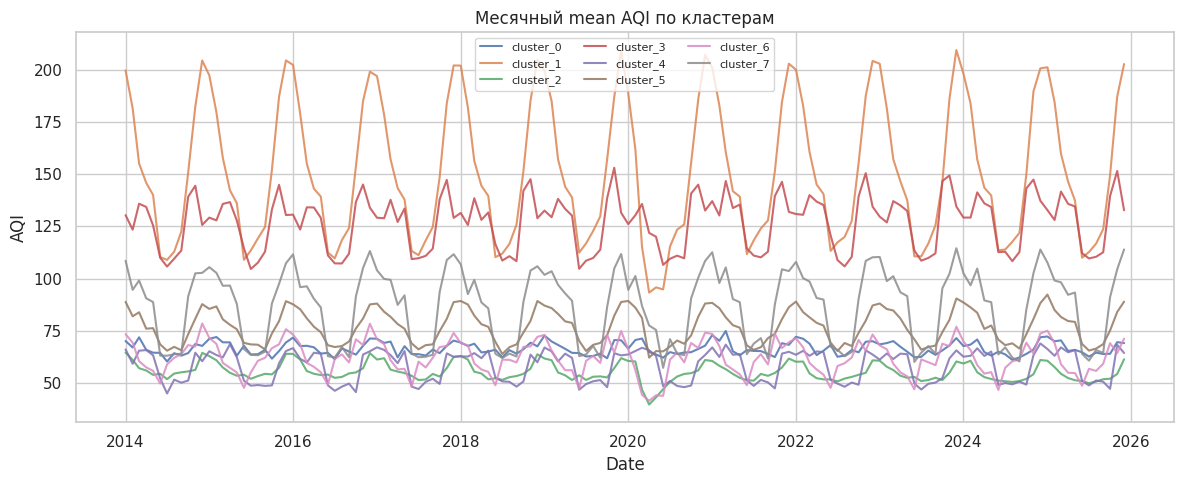

,mean,std,min,max
cluster_id,,,,
1,151.571340,33.033831,93.283843,209.524017
3,126.887462,13.012376,104.589041,153.130137
7,86.763834,17.651484,57.220472,114.551181
5,76.932913,8.054064,62.126543,92.314815
0,66.509090,3.124313,60.263889,74.875000
6,62.035603,8.019815,41.446701,78.472081
4,57.951333,7.454362,44.944000,68.912000
2,55.212522,4.292030,39.643750,64.579688



Краткий вывод:
- Профили AQI по кластерам заметно различаются — сегментация имеет смысл.
- Далее раздел 6.2 — диагностика временной структуры.


In [12]:
section_bar('6.1. Месячный AQI по кластерам')

if 'cluster_ts_monthly' not in globals():
    raise NameError('Сначала выполните ячейку 6.0.')

plt.figure(figsize=(12, 5))
for cid, part in cluster_ts_monthly.groupby('cluster_id'):
    plt.plot(part[DATE_COL], part[AQI_COLUMN], label=f'cluster_{cid}', alpha=0.85)
plt.title('Месячный mean AQI по кластерам')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

display(
    cluster_ts_monthly.groupby('cluster_id')[AQI_COLUMN]
    .agg(['mean', 'std', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

concise_conclusion([
    'Профили AQI по кластерам заметно различаются — сегментация имеет смысл.',
    'Далее раздел 6.2 — диагностика временной структуры.',
])


## 6.2. Временная диагностика по кластерам

После ячейки с **долгосрочным трендом** — четыре блока на месячной сетке AQI:
1. **6.2.1** — сезонность (месяц/квартал, mean ± std);
2. **6.2.2** — heatmap год × месяц;
3. **6.2.3** — коррелограммы ACF/PACF (ключевой лаг 12 мес.);
4. **6.2.4** — остатки, ADF, ARCH, Ljung-Box; **здесь** задаются группы A/B (`RESID_VARIANCE_GROUP`).



6.2. Долгосрочный тренд AQI


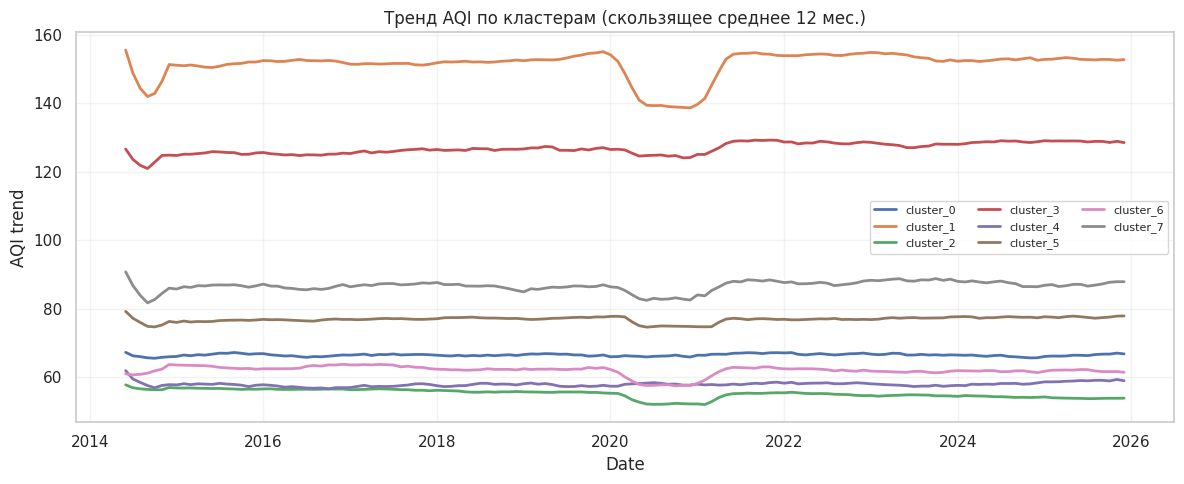


Краткий вывод:
- Долгосрочный уровень AQI по большинству кластеров относительно стабилен.
- У части кластеров заметны локальные провалы около 2020–2021 гг.


In [13]:
section_bar('6.2. Долгосрочный тренд AQI')

TREND_WINDOW_MONTHS = 12
MIN_PERIODS = 6

if 'cluster_ts_monthly' not in globals():
    raise NameError('Сначала выполните ячейку 6.0 (cluster_ts_monthly).')

trend_frames = []
for cid, part in cluster_ts_monthly.groupby('cluster_id'):
    s = part.set_index(DATE_COL)[AQI_COLUMN].sort_index()
    trend = s.rolling(TREND_WINDOW_MONTHS, min_periods=MIN_PERIODS).mean()
    trend_frames.append(
        pd.DataFrame({DATE_COL: trend.index, 'cluster_id': int(cid), 'aqi_trend': trend.values})
    )
cluster_trend_df = pd.concat(trend_frames, ignore_index=True)

plt.figure(figsize=(12, 5))
for cid, part in cluster_trend_df.groupby('cluster_id'):
    plt.plot(part[DATE_COL], part['aqi_trend'], label=f'cluster_{cid}', linewidth=2)
plt.title(f'Тренд AQI по кластерам (скользящее среднее {TREND_WINDOW_MONTHS} мес.)')
plt.xlabel('Date')
plt.ylabel('AQI trend')
plt.legend(ncol=3, fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

concise_conclusion([
    'Долгосрочный уровень AQI по большинству кластеров относительно стабилен.',
    'У части кластеров заметны локальные провалы около 2020–2021 гг.',
])



6.2.1. Сезонность
Амплитуда сезонности (max-min по месяцам), все кластеры:


,season_range
cluster_id,
1,94.182496
7,46.604331
3,38.988584
6,26.544839
5,22.284979
4,16.408667
2,11.031380
0,7.554109


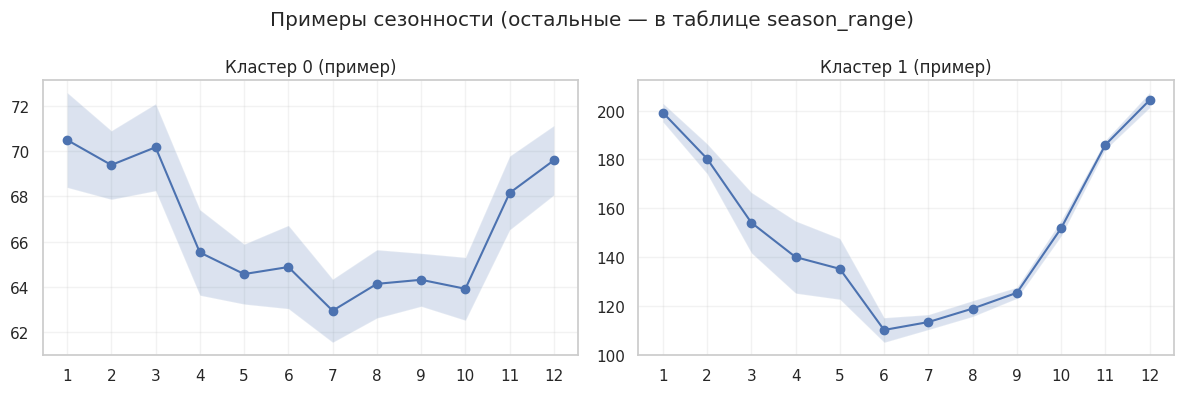


Краткий вывод:
- Сезонные профили различаются по форме и амплитуде — оправданы модели с периодом 12 мес.


In [14]:
section_bar('6.2.1. Сезонность')

cluster_month_profile = (
    cluster_ts_monthly.assign(month=cluster_ts_monthly[DATE_COL].dt.month)
    .groupby(['cluster_id', 'month'])[AQI_COLUMN]
    .agg(['mean', 'std'])
    .reset_index()
)
season_amp = (
    cluster_month_profile.groupby('cluster_id')['mean']
    .agg(lambda s: float(s.max() - s.min()))
    .rename('season_range')
    .sort_values(ascending=False)
)
print('Амплитуда сезонности (max-min по месяцам), все кластеры:')
display(season_amp.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cid in zip(axes, PLOT_EXAMPLE_CLUSTERS):
    part = cluster_month_profile[cluster_month_profile['cluster_id'] == cid]
    ax.plot(part['month'], part['mean'], marker='o', label='mean')
    ax.fill_between(
        part['month'],
        part['mean'] - part['std'].fillna(0),
        part['mean'] + part['std'].fillna(0),
        alpha=0.2,
    )
    ax.set_title(f'Кластер {cid} (пример)')
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=0.25)
plt.suptitle('Примеры сезонности (остальные — в таблице season_range)')
plt.tight_layout()
plt.show()

concise_conclusion([
    'Сезонные профили различаются по форме и амплитуде — оправданы модели с периодом 12 мес.',
])



6.2.2. Heatmap год × месяц


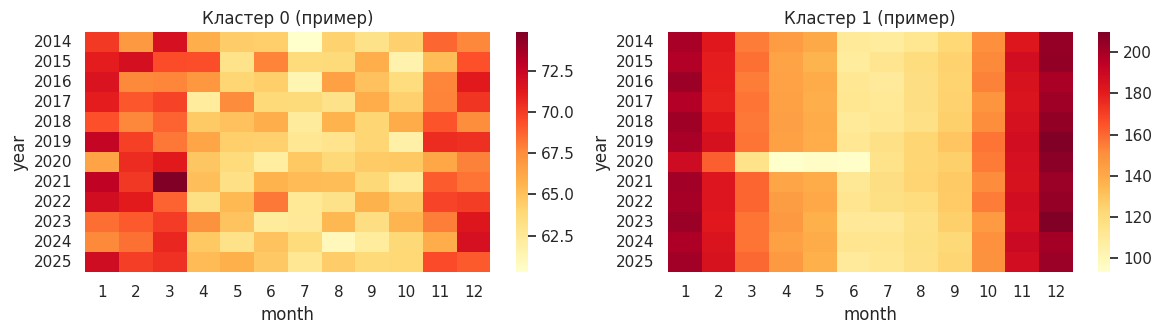


Краткий вывод:
- Провалы 2015 и 2020–2021 выражены неравномерно — шоки зависят от сегмента.


In [15]:
section_bar('6.2.2. Heatmap год × месяц')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, cid in zip(axes, PLOT_EXAMPLE_CLUSTERS):
    part = cluster_ts_monthly[cluster_ts_monthly['cluster_id'] == cid].copy()
    part['year'] = part[DATE_COL].dt.year
    part['month'] = part[DATE_COL].dt.month
    heat = part.pivot_table(index='year', columns='month', values=AQI_COLUMN, aggfunc='mean')
    sns.heatmap(heat, cmap='YlOrRd', ax=ax, cbar=True)
    ax.set_title(f'Кластер {cid} (пример)')
plt.tight_layout()
plt.show()

concise_conclusion([
    'Провалы 2015 и 2020–2021 выражены неравномерно — шоки зависят от сегмента.',
])



6.2.3. ACF / PACF


,lag_1,lag_3,lag_6,lag_12
cluster_id,,,,
0,0.494,0.004,-0.595,0.631
1,0.814,-0.032,-0.829,0.867
2,0.729,-0.032,-0.472,0.738
3,0.560,-0.315,-0.164,0.869
4,0.606,-0.022,-0.661,0.854
5,0.787,-0.040,-0.839,0.839
6,0.653,0.017,-0.737,0.801
7,0.721,-0.061,-0.756,0.873


,lag_1,lag_3,lag_6,lag_12
cluster_id,,,,
0,0.494,-0.178,-0.313,0.175
1,0.814,-0.272,-0.250,0.058
2,0.729,-0.265,-0.112,0.157
3,0.560,-0.241,-0.249,0.638
4,0.606,-0.203,-0.171,0.514
5,0.787,-0.470,-0.323,0.099
6,0.653,-0.402,-0.289,0.395
7,0.721,-0.436,-0.349,0.396


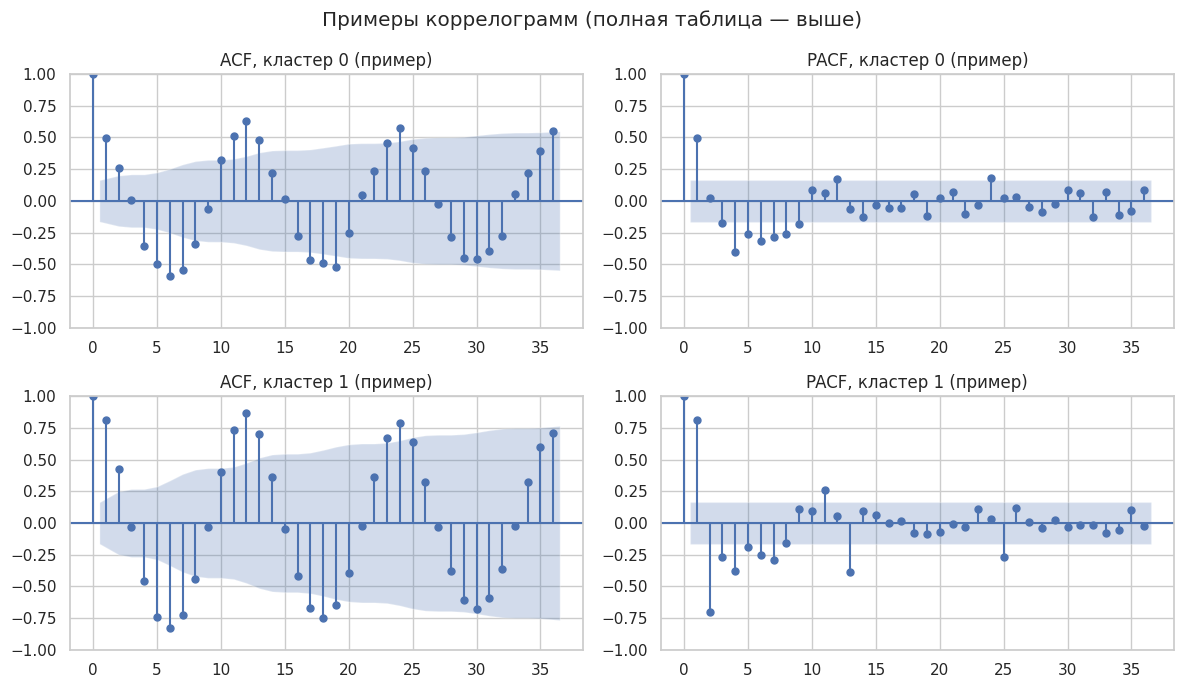


Краткий вывод:
- Пик ACF около 12 мес. — годовая сезонность; для моделей разумно m=12 по кластерам.


In [16]:
section_bar('6.2.3. ACF / PACF')

LAGS_MONTHLY = 36
KEY_LAGS_MONTHLY = [1, 3, 6, 12]

acf_key_rows, pacf_key_rows = [], []
cluster_ids_all = sorted(cluster_ts_monthly['cluster_id'].dropna().unique())

for cid in cluster_ids_all:
    monthly_aqi = (
        cluster_ts_monthly[cluster_ts_monthly['cluster_id'] == cid]
        .set_index(DATE_COL)[AQI_COLUMN].sort_index().dropna()
    )
    if len(monthly_aqi) < LAGS_MONTHLY + 5:
        continue
    acf_m = acf(monthly_aqi, nlags=LAGS_MONTHLY, fft=True)
    pacf_m = pacf(monthly_aqi, nlags=LAGS_MONTHLY, method='ywm')
    acf_key_rows.append({'cluster_id': int(cid), **{f'lag_{k}': acf_m[k] for k in KEY_LAGS_MONTHLY}})
    pacf_key_rows.append({'cluster_id': int(cid), **{f'lag_{k}': pacf_m[k] for k in KEY_LAGS_MONTHLY}})

if acf_key_rows:
    display(pd.DataFrame(acf_key_rows).set_index('cluster_id').round(3))
    display(pd.DataFrame(pacf_key_rows).set_index('cluster_id').round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row_i, cid in enumerate(PLOT_EXAMPLE_CLUSTERS):
    monthly_aqi = (
        cluster_ts_monthly[cluster_ts_monthly['cluster_id'] == cid]
        .set_index(DATE_COL)[AQI_COLUMN].sort_index().dropna()
    )
    plot_acf(monthly_aqi, lags=LAGS_MONTHLY, ax=axes[row_i, 0])
    axes[row_i, 0].set_title(f'ACF, кластер {cid} (пример)')
    plot_pacf(monthly_aqi, lags=LAGS_MONTHLY, ax=axes[row_i, 1], method='ywm')
    axes[row_i, 1].set_title(f'PACF, кластер {cid} (пример)')
plt.suptitle('Примеры коррелограмм (полная таблица — выше)')
plt.tight_layout()
plt.show()

concise_conclusion([
    'Пик ACF около 12 мес. — годовая сезонность; для моделей разумно m=12 по кластерам.',
])



6.2.4. Остатки и тесты


,adf_resid_p,arch_p,ljung_box_p_12,остатки_дисперсия,группа
cluster_id,,,,,
0,0.0,0.4692,0.0002,гомоскедастичны,A
1,0.0,0.0000,0.0000,гетероскедастичны,B
2,0.0,0.0001,0.0000,гетероскедастичны,B
3,0.0,0.2276,0.1059,гомоскедастичны,A
4,0.0,0.6903,0.0264,гомоскедастичны,A
5,0.0,0.0486,0.0000,гетероскедастичны,B
6,0.0,0.0000,0.0000,гетероскедастичны,B
7,0.0,0.0001,0.1106,гетероскедастичны,B


Группа A: кластеры [0, 3, 4]
Группа B: кластеры [1, 2, 5, 6, 7]


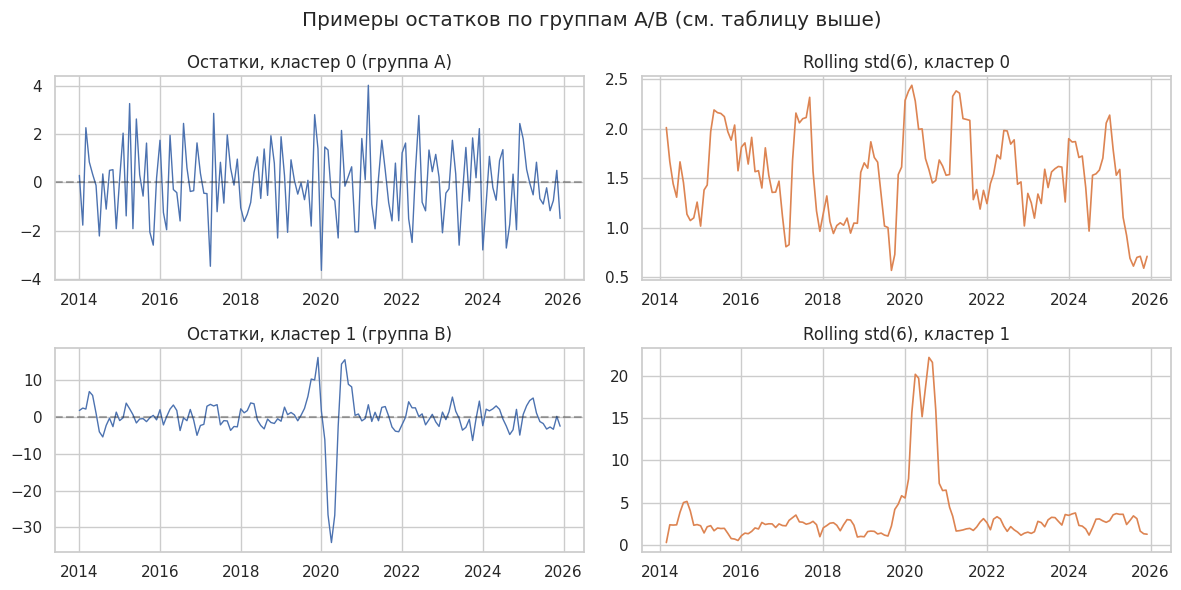


Краткий вывод:
- Группы A/B заданы здесь: A — [0, 3, 4], B — [1, 2, 5, 6, 7] (ARCH p < 0.05 → B).
- RESID_VARIANCE_GROUP доступен в разделах 6.3–7.
- Далее: 6.3 (типы моделей), 6.4 (MAE), 6.5 (прогноз), 7 (сохранение).


In [17]:
section_bar('6.2.4. Остатки и тесты')

DIAG_ALPHA = 0.05
resid_diag_rows = []
cluster_ids_all = sorted(cluster_ts_monthly['cluster_id'].dropna().unique())

for cid in cluster_ids_all:
    s = (
        cluster_ts_monthly[cluster_ts_monthly['cluster_id'] == cid]
        .set_index(DATE_COL)[AQI_COLUMN].sort_index().dropna()
    )
    if len(s) < 24:
        continue
    decomp = seasonal_decompose(s, model='additive', period=12, extrapolate_trend='freq')
    resid = decomp.resid.dropna()
    adf_resid_p = float(adfuller(resid, autolag='AIC')[1])
    arch_p_val = float(het_arch(resid.values, nlags=12)[1])
    ljung_p = float(acorr_ljungbox(resid, lags=[12], return_df=True)['lb_pvalue'].iloc[0])
    var_label = 'гетероскедастичны' if arch_p_val < DIAG_ALPHA else 'гомоскедастичны'
    group_code = 'B' if var_label == 'гетероскедастичны' else 'A'
    resid_diag_rows.append({
        'cluster_id': int(cid),
        'adf_resid_p': adf_resid_p,
        'arch_p': arch_p_val,
        'ljung_box_p_12': ljung_p,
        'остатки_дисперсия': var_label,
        'группа': group_code,
    })

resid_diag_df = pd.DataFrame(resid_diag_rows).set_index('cluster_id').round(4)
display(resid_diag_df)

# Группы A/B — только по результатам тестов в этой ячейке (ARCH, порог DIAG_ALPHA)
RESID_VARIANCE_GROUP = {
    int(cid): (
        row['группа'],
        row['остатки_дисперсия'],
    )
    for cid, row in resid_diag_df.iterrows()
}

clusters_by_group = {}
for cid, (code, _label) in RESID_VARIANCE_GROUP.items():
    clusters_by_group.setdefault(code, []).append(int(cid))
for code in sorted(clusters_by_group):
    print(f"Группа {code}: кластеры {sorted(clusters_by_group[code])}")

CLUSTER_EXAMPLES = {
    code: sorted(clusters_by_group[code])[0]
    for code in clusters_by_group
    if clusters_by_group[code]
}

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for row_i, (label, cid) in enumerate(CLUSTER_EXAMPLES.items()):
    s = cluster_ts_monthly[cluster_ts_monthly['cluster_id'] == cid].set_index(DATE_COL)[AQI_COLUMN].sort_index()
    decomp = seasonal_decompose(s.dropna(), model='additive', period=12, extrapolate_trend='freq')
    resid = decomp.resid.dropna()
    axes[row_i, 0].plot(resid.index, resid.values, lw=1)
    axes[row_i, 0].axhline(0, color='k', ls='--', alpha=0.35)
    axes[row_i, 0].set_title(f'Остатки, кластер {cid} (группа {label})')
    roll_std = resid.rolling(6, min_periods=3).std()
    axes[row_i, 1].plot(roll_std.index, roll_std.values, lw=1.2, color='C1')
    axes[row_i, 1].set_title(f'Rolling std(6), кластер {cid}')
plt.suptitle('Примеры остатков по группам A/B (см. таблицу выше)')
plt.tight_layout()
plt.show()

concise_conclusion([
    f'Группы A/B заданы здесь: A — {sorted(clusters_by_group.get("A", []))}, B — {sorted(clusters_by_group.get("B", []))} (ARCH p < {DIAG_ALPHA} → B).',
    'RESID_VARIANCE_GROUP доступен в разделах 6.3–7.',
    'Далее: 6.3 (типы моделей), 6.4 (MAE), 6.5 (прогноз), 7 (сохранение).',
])


**Связка разделов:** 6.2.4 (группы A/B по остаткам) → 6.3 (какие семейства уместны) → 6.4 (взвешенная временная CV, 5 моделей) → 6.5 / 7 (прогноз и сохранение).


## 6.3. Типы временных моделей

По итогам **6.2.4** кластеры делим на две группы по **остаткам** после снятия сезонности (см. таблицу и печать «Группа A/B: кластеры …» в ячейке **6.2.4**):

- **Группа A** — остатки **гомоскедастичны** (разброс ошибки примерно одинаковый во времени).
- **Группа B** — остатки **гетероскедастичны** (в одни периоды ошибка крупнее, в другие — меньше).

У **всех** кластеров остатки **стационарны**: после учёта тренда и годового цикла ряд не «уезжает» бесконечно. Прогнозируем **6 показателей** на **месячной** сетке (5 загрязнителей + AQI).


### Метрика качества: почему MAE

Чтобы сравнить пригодные типы моделей **объективно**, в разделе **6.4** используем одну главную метрику на hold-out — последние **12 месяцев**, которые модель при обучении не видела.

**MAE (Mean Absolute Error, средняя абсолютная ошибка)** — среднее значение |факт − прогноз| по месяцам hold-out. Если MAE = 2 по AQI, в среднем прогноз промахивается примерно на 2 пункта индекса; для PM2.5 — на те же 2 μg/m³, что и единицы измерения в данных.

**Почему MAE, а не другие метрики:**

| Метрика | Роль у нас |
|---------|------------|
| **MAE** | **Главный критерий выбора** модели на кластер |
| **RMSE** | Вспомогательная: при близком MAE смотрим, нет ли редких крупных промахов (RMSE сильнее штрафует выбросы) |
| **MSE / RMSE как единственный критерий** | Не ставим во главу: в разделе 2 распределения загрязнителей часто **ненормальные**, есть выбросы — квадрат ошибки раздувает влияние единичных месяцев |
| **MAPE (%)** | Не главная: при малых концентрациях знаменатель нестабилен, проценты по разным загрязнителям сложно сравнивать в одной таблице |

**Мульти-выход (6 таргетов):** для каждого месяца hold-out считаем MAE отдельно по PM2.5, PM10, NO2, SO2, O3 и AQI, затем берём **среднее по шести** (`mae_mean`). Так одна модель не выигрывает только за счёт хорошего AQI при плохом прогнозе загрязнителей. Дополнительно полезно смотреть MAE **по каждому таргету** — для интерпретации, не для другого «победителя».

**Сравнение только внутри кластера:** MAE у кластера 2 и кластера 3 нельзя сопоставлять напрямую — разный средний уровень AQI. Кандидаты (Seasonal Naive, Holt–Winters, Ridge и др.) сравниваем **на одном и том же** `cluster_id`, одной и той же сетке MS и одном hold-out.

**Группа B и min/max:** MAE оценивает **уровень** прогноза. Ширину коридора (min/max) при гетероскедастичных остатках оцениваем **отдельно** (покрытие интервала, WLS, GARCH) — иначе можно выбрать точную модель среднего, но неверные границы.

---

### Группа A (гомоскедастичные остатки)

**Что видим в данных:** годовая сезонность выражена, долгосрочный тренд обычно не «ломает» ряд; разброс вокруг сезонного профиля относительно стабилен. Это хороший случай для классических моделей «тренд + сезон + случайный шум постоянной силы».

#### Пригодные типы моделей

| Тип | Почему подходит |
|-----|----------------|
| **Сезонный наивный прогноз** («как год назад в этом месяце») | Простая опора на главный годовой цикл; часто силён, если тренд слабый (кластеры 3, 4). |
| **Тройное экспоненциальное сглаживание** (тренд + сезон, период 12 мес.) | Прямо описывает то, что мы видим в 6.1: плавный тренд и повторяемость по месяцам. |
| **SARIMA / SARIMAX** | Учитывает сезон раз в 12 месяцев и автокорреляцию; SARIMAX — если позже добавим внешние факторы (погода, политика). |
| **Линейные модели** (лаги прошлых месяцев + календарь) | Удобны, когда важна «память» ряда и связь нескольких загрязнителей сразу (кластер 0). Ошибки по уровню часто ненормальны — оцениваем качество по **средней абсолютной ошибке**, а не по «идеальной кривой Гаусса». |
| **Prophet** | Наглядно отделяет тренд и годовую сезонность **по одному** показателю; годится для разбора и бенчмарка, но для 6 выходов нужно обучать **несколько** моделей. |
| **Бустинг** (деревья по лагам и дате) | Может чуть улучшить точность, если связи нелинейные; нужна осторожная проверка на hold-out, чтобы не переобучиться на короткой истории. |
 
#### Непригодные или слабые как основная модель

| Тип | Почему не берём в первую очередь |
|-----|----------------------------------|
| **ARIMA без сезонности** | Игнорирует главный эффект — повторение через 12 месяцев. |
| **Только Prophet на все 6 целей сразу** | Так не работает «из коробки»; для продакшна неудобно. |
| **Очень сложные нейросети** | Мало месяцев в истории; выигрыш сомнителен, объясняемость хуже. |

*Для группы A нет смысла строить отдельные модели только для «раздувающейся» дисперсии — по 6.2.4 разброс остатков уже стабилен.*

---

### Группа B (гетероскедастичные остатки)

**Что видим в данных:** годовой цикл есть, но **сила шума меняется** (шоки, разные годы по волатильности — см. heatmap 6.2.2). Прогноз **среднего** и прогноз **разброса (min/max)** — разные задачи.

#### Пригодные типы моделей

| Тип | Почему подходит |
|-----|----------------|
| **Сезонный наивный прогноз** | Часто хорошо бьёт **средний** уровень (кластеры 1, 2, 6); прост и устойчив. |
| **Линейные модели с лагами** | Хороши при сменах тренда и памяти месяца (кластеры 5, 7); качество — по MAE. |
| **Тройное сглаживание** | Может дать хорошую **точку** прогноза, но полосы «min/max» из неё **не всегда честные**, если шум то тихий, то громкий. |
| **SARIMA / SARIMAX** | Сезон + связь с прошлым; иногда помогает **логарифм** показателя, чтобы сгладить всплески. |
| **Бустинг** | Гибкий вариант для нелинейных эффектов; обязательно сравнивать с простыми моделями на последних 12 месяцах. |
| **Prophet** | Умеет гибкий тренд и сезон; полезен для анализа, но интервалы нужно **проверять** на hold-out. |
| **Взвешенные линейные модели (WLS)** | Больший вес «спокойным» месяцам, меньший — шумным; логично поверх линейной модели в группе B. |
| **ARCH / GARCH** | Не заменяют прогноз уровня, но помогают оценить, **насколько широкий** должен быть коридор min/max, когда волатильность меняется. |

#### Непригодные или слабые как единственное решение

| Тип | Почему не берём в первую очередь |
|-----|----------------------------------|
| **Только Holt–Winters с доверительными полосами** | Среднее может быть ок, а **ширина коридора** часто не совпадает с реальностью при меняющемся шуме. |
| **Только ARCH/GARCH** | Они про **разброс**, а не про сам уровень AQI и загрязнителей. |
| **ARIMA без сезона** | Теряется годовой цикл. |
| **Одна модель на все кластеры** | Паттерны шума и сезона **разные**; нужен routing по `cluster_id`. |

---

**Практический вывод:** для группы A разумны **простые сезонные** и **сглаживание**; для группы B — чаще **линейные/бустинг** и отдельная работа с разбросом (WLS, GARCH для min/max). Сравнение по **MAE** — **6.4**; сохранение — **7**.


## 6.4. Выбор модели по MAE

По обоснованию из **6.3** сравниваем **пригодные и реализованные** кандидаты в два шага: **6.4.1** — подбор гиперпараметров **внутри** каждого типа; **6.4.2** — выбор типа между **настроенными** победителями. Метрика — **взвешенная временная CV** (expanding window, test = **12 месяцев**, **`mae_mean`** по 6 таргетам). Колонка «группа» — из **RESID_VARIANCE_GROUP** (**6.2.4**).

### 6.4.1. Подбор гиперпараметров по типам

Для каждого `cluster_id` и каждого из **5 типов** перебираем **короткую сетку** (`cluster_forecast.hyperparam_grids()`): Seasonal Naive (fallback), Holt–Winters (trend/seasonal/damped), Ridge (`alpha`), GB (lr/depth/iter), WLS-Ridge (`alpha` × окно волатильности). Победитель типа — минимальный **cv_wmae** на той же CV, что и ниже.

### 6.4.2. Выбор типа между настроенными моделями

Сравниваем **по одной лучшей конфигурации на тип** (из 6.4.1) той же взвешенной CV. Итоговая таблица — группа A/B, победитель, **гиперпараметры победителя**, MAE; без столбцов `MAE_<тип>` по всем кандидатам.

### Взвешенная временная CV (линейные веса)

- **Expanding window:** train растёт, test — следующие 12 месяцев; последний фолд совпадает с «прогнозом с конца истории».
- **Линейные веса фолдов** (от старого к новому): при **F** фолдах веса пропорциональны **1, 2, …, F** (нормировка на сумму; при F=4 это **10% / 20% / 30% / 40%**). Недавние годы влияют на выбор модели сильнее.
- Победитель — минимальный **взвешенный** `mae_mean`; при равенстве — лучше на **последнем** фолде, затем `rmse_mean`.
- Колонка **`mae_last_holdout`** — MAE только на последних 12 мес. (без усреднения по CV), для сравнения.


### Кого сравниваем в таблице

**Вход для всех типов:** помесячная **панель кластера** — усреднённые по городам кластера **6 показателей** (PM2.5, PM10, NO₂, SO₂, O₃, AQI). Погода, CO₂, плотность населения и др. **в прогноз не входят** (только в кластеризацию, §4).

| Тип | Признаки / опора |
|-----|------------------|
| **SeasonalNaiveVector** | только **свой ряд**: значение **12 мес. назад** (fallback — последний месяц или среднее за 12) |
| **HoltWintersVector** | только **история своего ряда**: уровень + **сезон 12 мес.** [+ тренд по hp] |
| **RidgeMultiOutput** | **лаги** 1, 2, 3, 6, 12 и **скользящие средние** 3 и 6 мес. — **по каждому из 6 показателей**; плюс **month_sin**, **month_cos**, **time_idx**; прогноз — **рекурсивно** |
| **WLSRidgeMultiOutput** | те же признаки, что Ridge; отличие — **веса месяцев** при обучении (спокойные месяцы важнее) |
| **GradientBoostingVector** | те же признаки, что Ridge; **нелинейности** (бустинг) |

**Базовый класс в коде** (модуль sklearn / statsmodels / своя обёртка):

| Кандидат | Базовый класс (модуль) | Смысл |
|----------|------------------------|--------|
| **SeasonalNaiveVector** | — | прогноз «как год назад в этом месяце» (своя реализация в `cluster_forecast`) |
| **HoltWintersVector** | `statsmodels.tsa.holtwinters.ExponentialSmoothing` | тренд + сезон (period=12); 6 подмоделей по таргетам |
| **RidgeMultiOutput** | `sklearn.linear_model.Ridge` | линейная модель на лагах и календаре (`Pipeline` + `StandardScaler`; рекурсивный мульти-выход — свой) |
| **WLSRidgeMultiOutput** | `sklearn.linear_model.Ridge` | те же признаки, что Ridge; веса месяцев при `fit` — своя схема WLS |
| **GradientBoostingVector** | `sklearn.ensemble.HistGradientBoostingRegressor` | бустинг на тех же признаках (`MultiOutputRegressor` + `Pipeline` + `StandardScaler`) |

**Почему не все пункты из 6.3 в таблице:** в 6.3 перечислены **семейства**, которые теоретически уместны (в т.ч. Prophet, SARIMAX). В **6.4** — только то, что **одинаково** прогнозирует **вектор из 6 таргетов** на месячной сетке и уже есть в коде. **Prophet / SARIMA / SARIMAX** — по одному ряду на таргет (6× обучение), отдельный тяжёлый бенчмарк; **ARCH/GARCH** — про ширину коридора min/max, а не про MAE уровня.

### Доверительный интервал (min/max) и горизонт

В таблице ниже — **узкая сводка**: группа A/B, победитель, MAE и то, как ведёт себя **полоса min/max** для AQI у выбранной модели (колонки `ДИ_на_горизонте`, `aqi_±_h12`).

**`aqi_±_h12`** — на **последнем фолде** CV полуширина ориентировочного коридора AQI на **12-м** месяце test-окна (h = 12):
ширина эвристического min/max у победителя на дальнем горизонте hold-out.

**Как полоса меняется при отдалении от конца истории** (реализация в `cluster_forecast`):

- **`const` (Seasonal Naive):** ширина **не растёт** с горизонтом — на все 12 месяцев вперёд один и тот же ±z·σ, где σ — типичная ошибка «год назад в этом месяце» по истории. Допущение: разброс остатков **примерно постоянен** (согласуется с группой A в 6.2.4).
- **`√h` (Holt–Winters, Ridge, бустинг, WLS):** полуширина **растёт как √h** (h = 1…12) — чем дальше прогноз от последней точки истории, тем шире коридор: ошибка рекурсивного/сглаженного прогноза **накапливается** во времени.

**Почему так:** при `const` мы не моделируем накопление неопределённости по шагам; при `√h` — простая эвристика «случайная составляющая накапливается», как в классических интервалах для случайного блуждания. Это **не** полноценный GARCH и **не** гарантия покрытия 95%: для **группы B** (гетероскедастичные остатки в 6.2.4) реальный разброс ошибки **меняется по месяцам**, поэтому и `const`, и `√h` на дальнем горизонте могут быть **уже или шире** факта — в 6.5 полосу читаем как ориентир, не как строгий доверительный интервал.


In [18]:
section_bar('6.4.1. Подбор гиперпараметров по типам')

if 'cf' not in globals():
    raise NameError('Сначала выполните ячейку 6.0 (import cluster_forecast).')
if 'cluster_id' not in df.columns:
    raise ValueError('cluster_id не найден. Сначала выполните разделы 4 и 5.')

target_cols_eval = [c for c in TARGET_COLUMNS if c in df.columns]

type_tuning_results, tuned_by_cluster = cf.tune_hyperparams_weighted_cv(
    df,
    target_cols_eval,
    holdout=HOLDOUT_MONTHS,
    cv_min_train_months=CV_MIN_TRAIN_MONTHS,
    cv_n_folds=CV_N_FOLDS,
    model_candidates=MODEL_CANDIDATES,
)

display(type_tuning_results.round(4))

_hp_grids = cf.hyperparam_grids()
_n_clusters = int(df['cluster_id'].dropna().astype(int).nunique())
_n_types = len(MODEL_CANDIDATES)
_grid_sizes = {m: len(_hp_grids.get(m, [cf.default_model_config(m)])) for m in MODEL_CANDIDATES}
_per_type_formula = ' + '.join(
    f'{_n_clusters}×{_grid_sizes[m]}' if m != 'WLSRidgeMultiOutput' else f'{_n_clusters}×(3×3)'
    for m in MODEL_CANDIDATES
)
_total_hp_runs = _n_clusters * sum(_grid_sizes.values())

concise_conclusion([
    f'6.4.1: для каждого cluster_id × тип — лучшая конфигурация из короткой сетки (cv_wmae, {CV_N_FOLDS} фолда).',
    f'Число прогонов конфигураций: {_per_type_formula} = {_total_hp_runs} ({_n_clusters} кластеров × {_n_types} типов).',
    'Дальше 6.4.2: сравнение только настроенных победителей типов.',
])



6.4.1. Подбор гиперпараметров по типам


best_hyperparams  \
cluster_id model_type                                                                  
0          SeasonalNaiveVector                          fallback=last, season_lag=12   
           HoltWintersVector            damped_trend=False, seasonal=add, trend=None   
           RidgeMultiOutput                                              alpha=100.0   
           WLSRidgeMultiOutput                              alpha=10.0, vol_window=6   
           GradientBoostingVector  l2_regularization=0.0, learning_rate=0.03, max...   
1          SeasonalNaiveVector                          fallback=last, season_lag=12   
           HoltWintersVector             damped_trend=False, seasonal=mul, trend=add   
           RidgeMultiOutput                                                alpha=0.1   
           WLSRidgeMultiOutput                               alpha=1.0, vol_window=6   
           GradientBoostingVector  l2_regularization=0.1, learning_rate=0.08, max...   
2          SeasonalNaiveVector                          fallback=last, season_lag=12   
           HoltWintersVector             damped_trend=False, seasonal=mul, trend=add   
           RidgeMultiOutput                                               alpha=10.0   
           WLSRidgeMultiOutput                              alpha=10.0, vol_window=6   
           GradientBoostingVector  l2_regularization=0.0, learning_rate=0.03, max...   
3          SeasonalNaiveVector                          fallback=last, season_lag=12   
           HoltWintersVector             damped_trend=False, seasonal=mul, trend=add   
           RidgeMultiOutput                                                alpha=1.0   
           WLSRidgeMultiOutput                               alpha=1.0, vol_window=6   
           GradientBoostingVector  l2_regularization=0.0, learning_rate=0.12, max...   
4          SeasonalNaiveVector                          fallback=last, season_lag=12   
           HoltWintersVector             damped_trend=False, seasonal=mul, trend=add   
           RidgeMultiOutput                                               alpha=10.0   
           WLSRidgeMultiOutput                             alpha=10.0, vol_window=12   
           GradientBoostingVector  l2_regularization=0.0, learning_rate=0.05, max...   
5          SeasonalNaiveVector                          fallback=last, season_lag=12   
           HoltWintersVector             damped_trend=False, seasonal=add, trend=add   
           RidgeMultiOutput                                                alpha=1.0   
           WLSRidgeMultiOutput                               alpha=1.0, vol_window=6   
           GradientBoostingVector  l2_regularization=0.0, learning_rate=0.05, max...   
6          SeasonalNaiveVector                          fallback=last, season_lag=12   
           HoltWintersVector             damped_trend=False, seasonal=mul, trend=add   
           RidgeMultiOutput                                               alpha=10.0   
           WLSRidgeMultiOutput                              alpha=10.0, vol_window=6   
           GradientBoostingVector  l2_regularization=0.0, learning_rate=0.12, max...   
7          SeasonalNaiveVector                          fallback=last, season_lag=12   
           HoltWintersVector              damped_trend=True, seasonal=add, trend=add   
           RidgeMultiOutput                                                alpha=1.0   
           WLSRidgeMultiOutput                               alpha=0.1, vol_window=6   
           GradientBoostingVector  l2_regularization=0.0, learning_rate=0.05, max...   

                                                                    best_params_json  \
cluster_id model_type                                                                  
0          SeasonalNaiveVector     {"model_type": "SeasonalNaiveVector", "params"...   
           HoltWintersVector       {"model_type": "HoltWintersVector", "params": ...   
           RidgeMul


Краткий вывод:
- 6.4.1: для каждого cluster_id × тип — лучшая конфигурация из короткой сетки (cv_wmae, 4 фолда).
- Число прогонов конфигураций: 8×2 + 8×4 + 8×5 + 8×(3×3) + 8×6 = 208 (8 кластеров × 5 типов).
- Дальше 6.4.2: сравнение только настроенных победителей типов.


In [19]:
section_bar('6.4.2. Выбор типа между настроенными моделями')

if 'RESID_VARIANCE_GROUP' not in globals():
    raise NameError('Сначала выполните 6.2.4 (RESID_VARIANCE_GROUP).')
if 'tuned_by_cluster' not in globals():
    raise NameError('Сначала выполните 6.4.1 (tuned_by_cluster).')

model_selection_results = cf.select_models_weighted_cv(
    df,
    target_cols_eval,
    residual_variance_group=RESID_VARIANCE_GROUP,
    holdout=HOLDOUT_MONTHS,
    cv_min_train_months=CV_MIN_TRAIN_MONTHS,
    cv_n_folds=CV_N_FOLDS,
    model_candidates=MODEL_CANDIDATES,
    tuned_by_cluster=tuned_by_cluster,
    include_per_type_scores=False,
)

selection_view = model_selection_results[
    [
        'группа_остатков',
        'cv_n_folds',
        'cv_weights',
        'best_model',
        'best_hyperparams',
        'best_mae_mean',
        'mae_last_holdout',
        'ДИ_на_горизонте',
        'aqi_±_h12',
    ]
]
display(selection_view.round(4))

print('Интерпретация победителей по кластерам:')
for line in cf.interpret_model_selection_table(model_selection_results):
    print('•', line)

concise_conclusion([
    f'6.4.2: взвешенная CV — {CV_N_FOLDS} фолда; сравниваются типы с hp из 6.4.1.',
    'Победитель по cv_wmae; best_hyperparams — конфигурация для раздела 7.',
    'mae_last_holdout — только последний фолд (12 мес.) для сравнения.',
])


6.4.2. Выбор типа между настроенными моделями


,группа_остатков,cv_n_folds,cv_weights,best_model,best_hyperparams,best_mae_mean,mae_last_holdout,ДИ_на_горизонте,aqi_±_h12
cluster_id,,,,,,,,,
0,A,4,"0.10, 0.20, 0.30, 0.40",HoltWintersVector,"damped_trend=False, seasonal=add, trend=None",0.7088,0.5277,sqrt_h,10.9458
1,B,4,"0.10, 0.20, 0.30, 0.40",SeasonalNaiveVector,"fallback=last, season_lag=12",3.7577,1.6690,const,22.3142
2,B,4,"0.10, 0.20, 0.30, 0.40",SeasonalNaiveVector,"fallback=last, season_lag=12",0.7105,0.3436,const,5.5094
3,A,4,"0.10, 0.20, 0.30, 0.40",HoltWintersVector,"damped_trend=False, seasonal=mul, trend=add",2.2159,1.6399,sqrt_h,19.8502
4,A,4,"0.10, 0.20, 0.30, 0.40",HoltWintersVector,"damped_trend=False, seasonal=mul, trend=add",1.0143,0.9416,sqrt_h,12.7323
5,B,4,"0.10, 0.20, 0.30, 0.40",HoltWintersVector,"damped_trend=False, seasonal=add, trend=add",1.2321,0.9666,sqrt_h,14.4889
6,B,4,"0.10, 0.20, 0.30, 0.40",SeasonalNaiveVector,"fallback=last, season_lag=12",1.5985,0.9671,const,8.2337
7,B,4,"0.10, 0.20, 0.30, 0.40",HoltWintersVector,"damped_trend=True, seasonal=add, trend=add",1.7527,1.1396,sqrt_h,24.3387


Интерпретация победителей по кластерам:
• Кластер 0 (группа A): Holt–Winters — экспоненциальное сглаживание с сезонным циклом 12 мес. Настройки: без явного тренда — только уровень и сезон; аддитивная годовая сезонность (12 мес.). cv_wmae≈0.71; коридор min/max растёт как √h.
• Кластер 1 (группа B): Сезонный наивный — повторяет годовой профиль «как в этом месяце год назад». Настройки: опора на 12 мес. назад; если нет точки год назад — последний месяц. cv_wmae≈3.76; коридор min/max постоянной ширины на горизонте.
• Кластер 2 (группа B): Сезонный наивный — повторяет годовой профиль «как в этом месяце год назад». Настройки: опора на 12 мес. назад; если нет точки год назад — последний месяц. cv_wmae≈0.71; коридор min/max постоянной ширины на горизонте.
• Кластер 3 (группа A): Holt–Winters — экспоненциальное сглаживание с сезонным циклом 12 мес. Настройки: аддитивный тренд без затухания; мультипликативная годовая сезонность (12 мес.). cv_wmae≈2.22; коридор min/max растёт как √h.
• Кластер 4 (

## 6.5. Прогноз AQI на 12 месяцев

На **12 месяцев вперёд** от конца доступной истории строим прогноз **AQI** по каждому кластеру. Для кластера используется **победитель из 6.4** (`best_model` в таблице `model_selection_results`).

На графике (как на слайде 7, но **вся** история с 2014 г.):
- синяя линия — фактический месячный AQI (агрегат по кластеру);
- зелёная пунктирная — прогноз на **последние 12 мес.** hold-out (модель обучена без них);
- красная линия — точечный прогноз **+12 мес.** вперёд;
- заливка — **доверительный интервал** (min/max по выбранной модели);
- после 9 графиков — **таблица**: **σ AQI raw** (как в §5.1 — по всем наблюдениям город×месяц; у глобального ряда выше) и MAPE hold-out (% по 6 показателям).

Дополнительно **9-й график (референс)** — тот же формат, но ряд AQI по **всему датасету** (среднее по всем городам); тип модели — наиболее частый победитель из 6.4.

Прогноз вперёд переобучается на **полной** истории кластера (после выбора типа по CV в 6.4).



6.5. Прогноз AQI на 12 месяцев


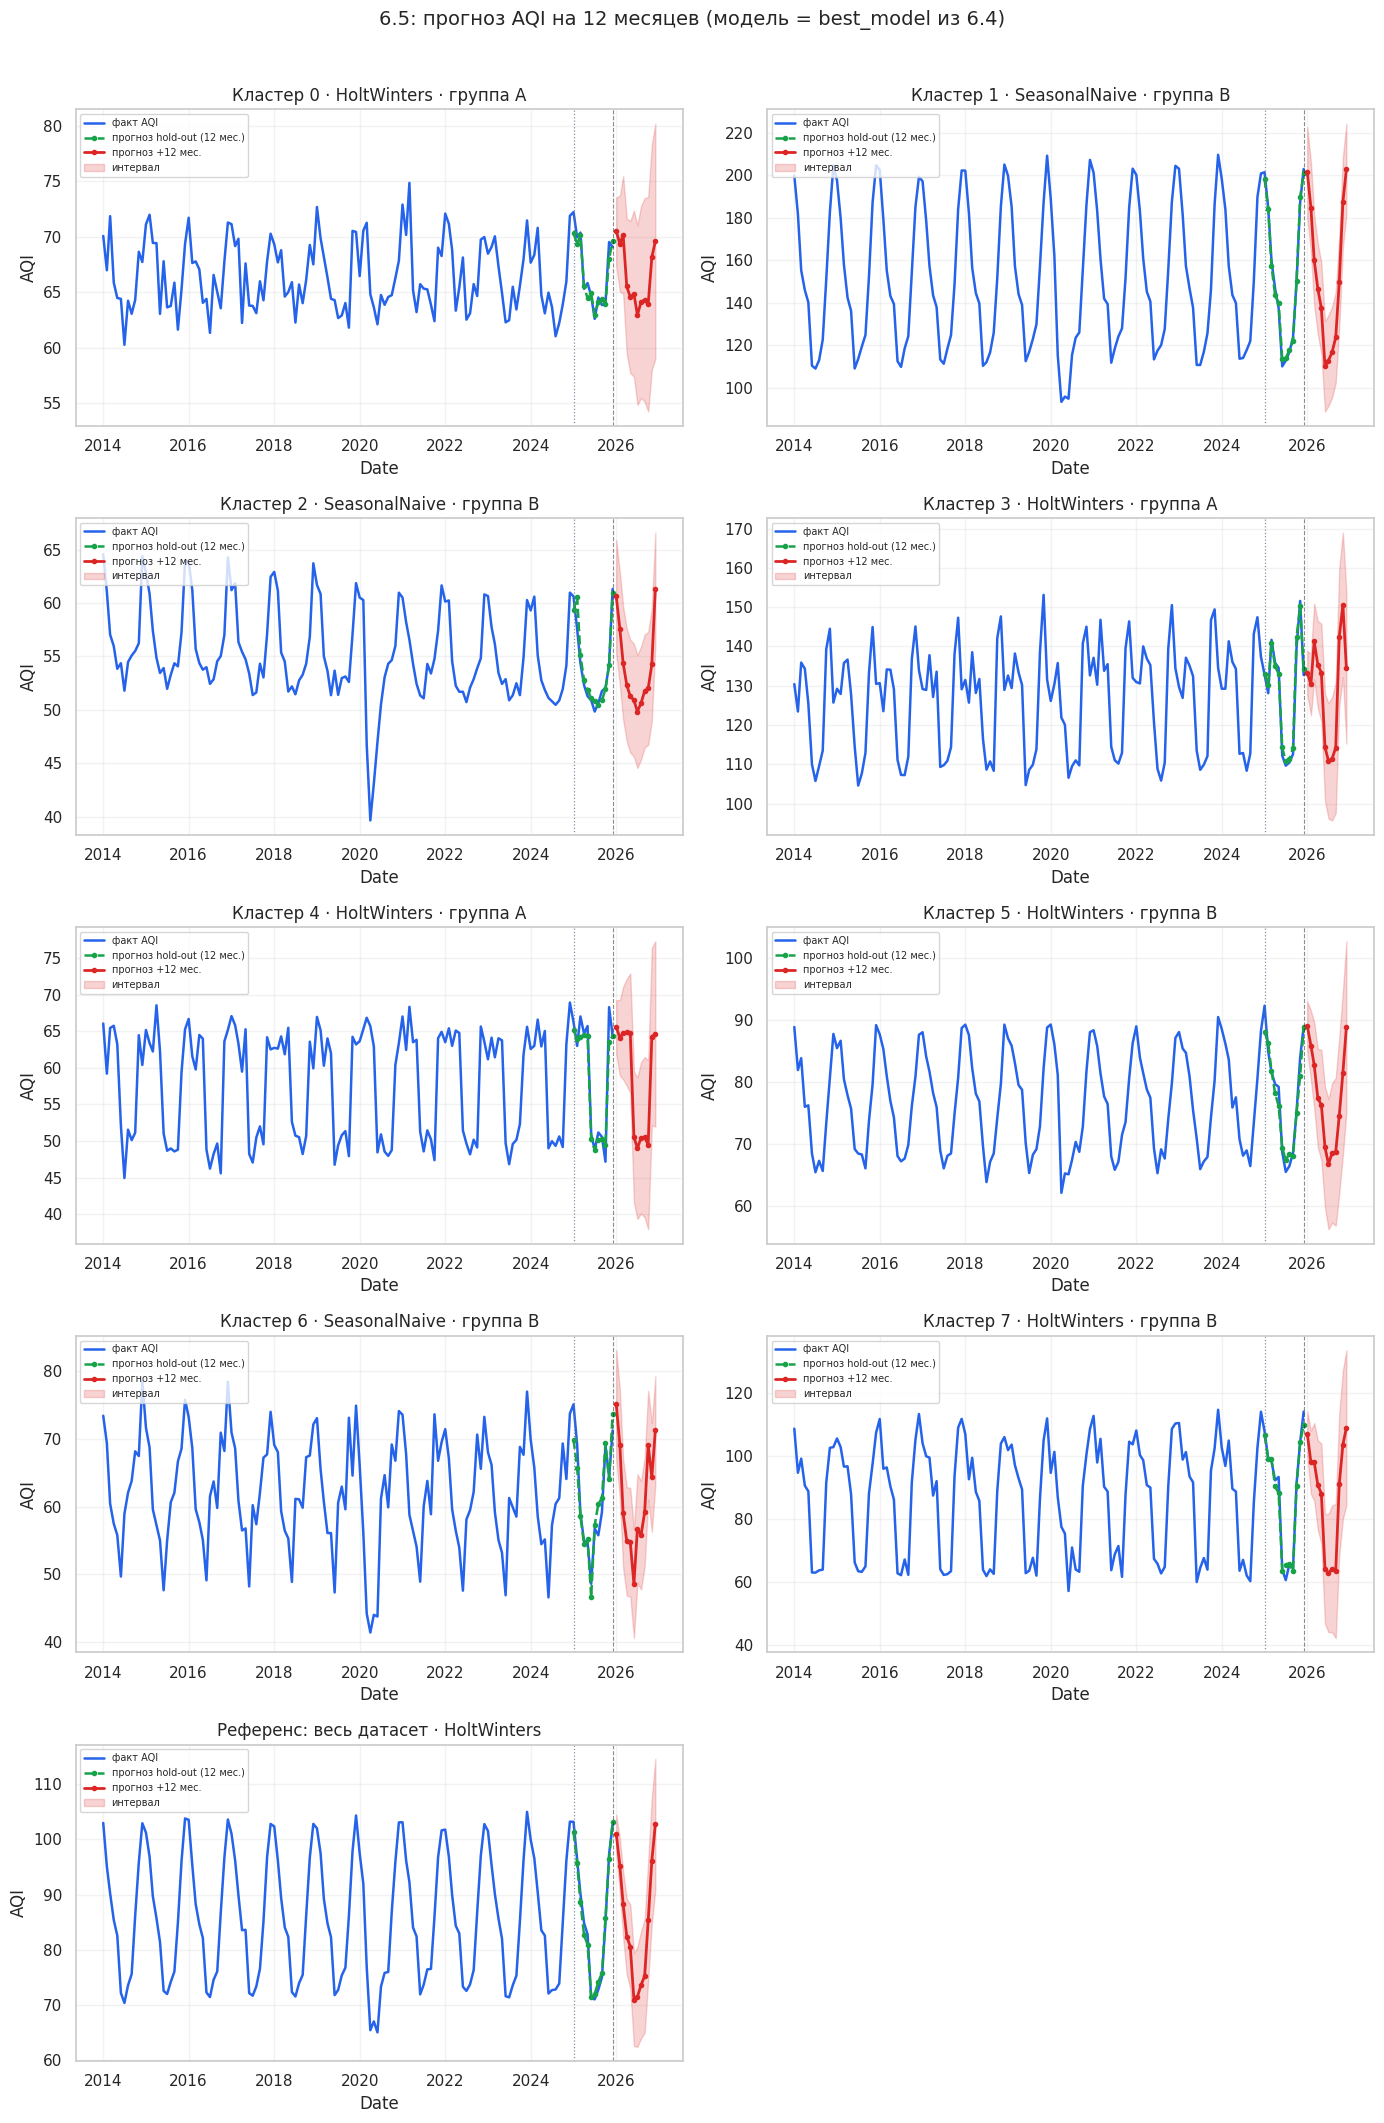

σ AQI raw — как в §5.1 (все наблюдения город×месяц); у референса — пул всего датасета (~61). Взвешенный σ внутри кластеров: 41.1. MAPE hold-out — среднее по 6 показателям и 12 мес.


,Сегмент,σ AQI raw (§5.1),"MAPE hold-out, %",Модель,Группа
0,Кластер 0,23.57,1.96,HoltWinters,A
1,Кластер 1,90.17,2.33,SeasonalNaive,B
2,Кластер 2,24.48,1.55,SeasonalNaive,B
3,Кластер 3,38.49,2.23,HoltWinters,A
4,Кластер 4,24.47,3.28,HoltWinters,A
5,Кластер 5,31.05,2.34,HoltWinters,B
6,Кластер 6,34.93,2.98,SeasonalNaive,B
7,Кластер 7,41.86,2.93,HoltWinters,B
8,Референс (весь датасет),60.73,1.75,HoltWinters,—



Краткий вывод:
- 6.5: таблица под графиками: σ AQI raw (§5.1) — у глобального пула выше, чем внутри большинства кластеров; MAPE hold-out отдельно.
- Референс: глобальный ряд, модель — самый частый победитель из 6.4.
- Следующий шаг — раздел 7: сохранение моделей и артефактов.


In [20]:
section_bar('6.5. Прогноз AQI на 12 месяцев')

from cluster_forecast.predict import predict_with_config


def _holdout_mape_pct(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """MAPE (%): среднее по 6 показателям и месяцам hold-out (как на слайде 7)."""
    denom = np.maximum(np.abs(y_true), 1e-6)
    return float(100.0 * np.mean(np.abs(y_true - y_pred) / denom))


if 'model_selection_results' not in globals():
    raise NameError('Сначала выполните ячейку 6.4 (таблица model_selection_results).')
if 'cluster_id' not in df.columns:
    raise ValueError('cluster_id не найден. Сначала выполните разделы 4 и 5.')

target_cols_eval = [c for c in TARGET_COLUMNS if c in df.columns]
aqi_idx = target_cols_eval.index(AQI_COLUMN)

cluster_ids_g5 = sorted(model_selection_results.index.astype(int).tolist())
n_cluster_plots = len(cluster_ids_g5)
n_plots = n_cluster_plots + 1  # +1 референс по всему датасету
ncols = 2
nrows = int(np.ceil(n_plots / ncols))
g5_metrics_rows: list[dict] = []

# σ как в §5.1: разброс по всем сырым наблюдениям (не помесячный ряд на графике)
global_aqi_std_raw = float(df[AQI_COLUMN].dropna().std(ddof=1))
cluster_aqi_std_raw = df.groupby('cluster_id')[AQI_COLUMN].std(ddof=1)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
axes = np.array(axes).reshape(-1)

for ax, cid in zip(axes[:n_cluster_plots], cluster_ids_g5):
    best = model_selection_results.loc[cid, 'best_model']
    grp = model_selection_results.loc[cid, 'группа_остатков'] if 'группа_остатков' in model_selection_results.columns else '?'

    hist_aqi = (
        cf.build_cluster_panel(df[df['cluster_id'] == cid], target_cols_eval)[AQI_COLUMN]
        .sort_index()
    )
    aqi_std_raw = float(cluster_aqi_std_raw.loc[cid])

    if pd.isna(best) or str(best) in ('SKIPPED_SHORT_SERIES', 'FAILED_ALL_MODELS'):
        ax.plot(hist_aqi.index, hist_aqi.values, color='C0', lw=1.5, label='факт AQI')
        ax.set_title(f'Кластер {cid}: нет модели ({best})')
        g5_metrics_rows.append(
            {
                'Сегмент': f'Кластер {cid}',
                'σ AQI raw (§5.1)': round(aqi_std_raw, 2),
                'MAPE hold-out, %': np.nan,
                'Модель': str(best),
                'Группа': grp,
            }
        )
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)
        continue

    Y = cf.build_cluster_panel(df[df['cluster_id'] == cid], target_cols_eval)
    best_cfg = cf.model_config_from_json(
        model_selection_results.loc[cid, 'best_params_json'],
        str(best),
    )

    try:
        train_hold = Y.iloc[:-HOLDOUT_MONTHS]
        test_hold = Y.iloc[-HOLDOUT_MONTHS:]
        pred_hold = predict_with_config(train_hold, test_hold.index, best_cfg)
        holdout_mape = _holdout_mape_pct(test_hold.values, pred_hold)

        future_idx, mean, lo, hi = cf.forecast_panel_with_intervals(
            Y, str(best), HORIZON_MONTHS, target_cols_eval, config=best_cfg
        )
        future_idx = pd.date_range(
            Y.index[-1] + pd.DateOffset(months=1),
            periods=HORIZON_MONTHS,
            freq='MS',
        )
        fc_mean = mean[:, aqi_idx]
        fc_lo = lo[:, aqi_idx]
        fc_hi = hi[:, aqi_idx]
        pred_hold_aqi = pred_hold[:, aqi_idx]

        ax.plot(hist_aqi.index, hist_aqi.values, color='#2563EB', lw=1.8, label='факт AQI')
        ax.plot(
            test_hold.index,
            pred_hold_aqi,
            color='#16A34A',
            lw=1.8,
            ls='--',
            marker='o',
            ms=3,
            label='прогноз hold-out (12 мес.)',
        )
        ax.plot(future_idx, fc_mean, color='#DC2626', lw=2, marker='o', ms=3, label='прогноз +12 мес.')
        ax.fill_between(future_idx, fc_lo, fc_hi, color='#DC2626', alpha=0.2, label='интервал')
        ax.axvline(test_hold.index[0], color='#64748B', ls=':', lw=0.9, alpha=0.8)
        ax.axvline(Y.index.max(), color='k', ls='--', lw=0.8, alpha=0.5)
        short_model = str(best).replace('Vector', '')
        ax.set_title(f'Кластер {cid} · {short_model} · группа {grp}')
        g5_metrics_rows.append(
            {
                'Сегмент': f'Кластер {cid}',
                'σ AQI raw (§5.1)': round(aqi_std_raw, 2),
                'MAPE hold-out, %': round(holdout_mape, 2),
                'Модель': short_model,
                'Группа': grp,
            }
        )
    except Exception as exc:
        ax.plot(hist_aqi.index, hist_aqi.values, color='C0', lw=1.5)
        ax.set_title(f'Кластер {cid}: ошибка прогноза ({best})')
        g5_metrics_rows.append(
            {
                'Сегмент': f'Кластер {cid}',
                'σ AQI raw (§5.1)': round(aqi_std_raw, 2),
                'MAPE hold-out, %': np.nan,
                'Модель': str(best).replace('Vector', ''),
                'Группа': grp,
            }
        )
        ax.text(0.02, 0.95, str(exc)[:80], transform=ax.transAxes, fontsize=8, va='top')

    ax.set_xlabel('Date')
    ax.set_ylabel('AQI')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.25)

# 9-й график: глобальный ряд (среднее по всем городам), тот же формат, что у кластеров
ax_ref = axes[n_cluster_plots]
Y_global = cf.build_cluster_panel(df, target_cols_eval)
hist_global = Y_global[AQI_COLUMN].sort_index()
aqi_std_global_raw = global_aqi_std_raw

valid_best = model_selection_results['best_model'].dropna()
valid_best = valid_best[~valid_best.astype(str).isin(('SKIPPED_SHORT_SERIES', 'FAILED_ALL_MODELS'))]
if valid_best.empty:
    ref_model, ref_cfg = None, None
else:
    ref_model = str(valid_best.mode().iloc[0])
    ref_row = model_selection_results[model_selection_results['best_model'] == ref_model].iloc[0]
    ref_cfg = cf.model_config_from_json(ref_row['best_params_json'], ref_model)

try:
    if ref_model is None:
        raise ValueError('нет валидной модели в 6.4 для референса')

    train_hold_g = Y_global.iloc[:-HOLDOUT_MONTHS]
    test_hold_g = Y_global.iloc[-HOLDOUT_MONTHS:]
    pred_hold_g = predict_with_config(train_hold_g, test_hold_g.index, ref_cfg)
    holdout_mape_g = _holdout_mape_pct(test_hold_g.values, pred_hold_g)

    future_idx_g, mean_g, lo_g, hi_g = cf.forecast_panel_with_intervals(
        Y_global, ref_model, HORIZON_MONTHS, target_cols_eval, config=ref_cfg
    )
    future_idx_g = pd.date_range(
        Y_global.index[-1] + pd.DateOffset(months=1),
        periods=HORIZON_MONTHS,
        freq='MS',
    )
    fc_mean_g = mean_g[:, aqi_idx]
    fc_lo_g = lo_g[:, aqi_idx]
    fc_hi_g = hi_g[:, aqi_idx]
    pred_hold_aqi_g = pred_hold_g[:, aqi_idx]

    ax_ref.plot(hist_global.index, hist_global.values, color='#2563EB', lw=1.8, label='факт AQI')
    ax_ref.plot(
        test_hold_g.index,
        pred_hold_aqi_g,
        color='#16A34A',
        lw=1.8,
        ls='--',
        marker='o',
        ms=3,
        label='прогноз hold-out (12 мес.)',
    )
    ax_ref.plot(future_idx_g, fc_mean_g, color='#DC2626', lw=2, marker='o', ms=3, label='прогноз +12 мес.')
    ax_ref.fill_between(future_idx_g, fc_lo_g, fc_hi_g, color='#DC2626', alpha=0.2, label='интервал')
    ax_ref.axvline(test_hold_g.index[0], color='#64748B', ls=':', lw=0.9, alpha=0.8)
    ax_ref.axvline(Y_global.index.max(), color='k', ls='--', lw=0.8, alpha=0.5)
    short_ref = ref_model.replace('Vector', '')
    ax_ref.set_title(f'Референс: весь датасет · {short_ref}')
    g5_metrics_rows.append(
        {
            'Сегмент': 'Референс (весь датасет)',
            'σ AQI raw (§5.1)': round(aqi_std_global_raw, 2),
            'MAPE hold-out, %': round(holdout_mape_g, 2),
            'Модель': short_ref,
            'Группа': '—',
        }
    )
except Exception as exc:
    ax_ref.plot(hist_global.index, hist_global.values, color='C0', lw=1.5, label='факт AQI')
    ax_ref.set_title('Референс: весь датасет — ошибка прогноза')
    g5_metrics_rows.append(
        {
            'Сегмент': 'Референс (весь датасет)',
            'σ AQI raw (§5.1)': round(aqi_std_global_raw, 2),
            'MAPE hold-out, %': np.nan,
            'Модель': '—',
            'Группа': '—',
        }
    )
    ax_ref.text(0.02, 0.95, str(exc)[:80], transform=ax_ref.transAxes, fontsize=8, va='top')

ax_ref.set_xlabel('Date')
ax_ref.set_ylabel('AQI')
ax_ref.legend(fontsize=7, loc='upper left')
ax_ref.grid(alpha=0.25)

for j in range(n_plots, len(axes)):
    axes[j].axis('off')

fig.suptitle('6.5: прогноз AQI на 12 месяцев (модель = best_model из 6.4)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

g5_metrics = pd.DataFrame(g5_metrics_rows)
weighted_within_aqi_std = float(
    np.average(cluster_aqi_std_raw, weights=df.groupby('cluster_id')[AQI_COLUMN].size())
)
print(
    'σ AQI raw — как в §5.1 (все наблюдения город×месяц); у референса — пул всего датасета (~61). '
    f'Взвешенный σ внутри кластеров: {weighted_within_aqi_std:.1f}. '
    'MAPE hold-out — среднее по 6 показателям и 12 мес.'
)
display(g5_metrics)

concise_conclusion([
    '6.5: таблица под графиками: σ AQI raw (§5.1) — у глобального пула выше, чем внутри большинства кластеров; MAPE hold-out отдельно.',
    'Референс: глобальный ряд, модель — самый частый победитель из 6.4.',
    'Следующий шаг — раздел 7: сохранение моделей и артефактов.',
])


### Ремарка про полосу min/max на графиках

На графиках 6.5 **залитая область** — это примерный коридор вокруг прогноза. Он строится по ошибкам модели на уже известной истории.

**Группа A** (кластеры из **6.2.4**). Разброс ошибки от месяца к месяцу меняется слабо — серый коридор на графике обычно уместен.

**Группа B** (кластеры из **6.2.4**). Разброс ошибки **сильнее меняется со временем**. Красная линия — прогноз среднего AQI; серую полосу лучше воспринимать как **наглядную подсказку**, а не как точную границу min/max.

**Почему отдельный GARCH не реализуем:**

1. Рядов много (6 показателей × 8 кластеров) — полноценный GARCH на каждый сильно усложнит код.
2. Задача раздела **6** — сравнить модели по **MAE** (6.4) и показать годовой прогноз (6.5); GARCH нужен в основном для min/max, а не для точности среднего.
3. WLS для группы B помогает при обучении **среднего**, но **не заменяет** прогноз разброса на будущие месяцы.

**Итог:** в **6.5** и **7** модели не меняем, интервалы оставляем как есть. Для группы B полоса на графике — **упрощение** (см. **6.2.4**).


## 7. Обучение и сохранение моделей

После **6.4–6.5** для каждого `cluster_id` сохраняем **ту же модель**, что выбрана в 6.4 (`best_model` в `model_selection_results`): переобучение на **полной** истории и прогноз на **12 месяцев** вперёд.

**5 кандидатов** (как в 6.4): Seasonal Naive, Holt–Winters, Ridge, Gradient Boosting, WLS-Ridge — мульти-выход на **5 загрязнителей + AQI**.

Пайплайн на кластер:
1. месячный ряд `Y[t, 6]` по кластеру;
2. тип модели = `model_selection_results.loc[cluster_id, 'best_model']` (без повторного отбора на hold-out);
3. fit на всей истории → `future_months` с value / min / max и `aqi_bucket`;
4. один файл `cluster_{id}__multioutput.joblib` в `models/`.

Дополнительно: `city_to_cluster_id.json`, `country_city_to_cluster_id.json`, `aqi_bucket_specs.json`, сводка `cluster_model_selection_results.csv`.

**Интервалы min/max** — те же упрощённые, что в **6.5** (для группы B см. ремарку там же; GARCH в проекте не реализуем).


In [21]:
section_bar('7. Сохранение моделей (финал)')

if 'cf' not in globals():
    raise NameError('Сначала выполните ячейку 6.0.')

if "cluster_id" not in df.columns:
    raise ValueError("cluster_id не найден. Сначала выполните разделы 4 и 5.")
if "model_selection_results" not in globals():
    raise NameError("Сначала выполните 6.4 (таблица model_selection_results).")

target_columns = [c for c in TARGET_COLUMNS if c in df.columns]
if AQI_COLUMN not in target_columns:
    raise ValueError("Колонка AQI обязательна в target_columns")

models_dir = Path.cwd().parent / "models"
results_df = cf.train_cluster_models(
    df=df,
    city_profile=city_profile,
    models_dir=models_dir,
    target_columns=target_columns,
    holdout=12,
    future_horizon=12,
    model_by_cluster=model_selection_results,
)

display(results_df.drop(columns=['artifact_path'], errors='ignore'))

h_vs_selection = (
    pd.DataFrame({
        "selection_best_model": model_selection_results["best_model"],
        "h_saved_model": results_df.set_index("cluster_id")["model"],
        "selection_mae_mean": model_selection_results["best_mae_mean"],
        "h_holdout_mae_mean": results_df.set_index("cluster_id")["mae_mean"],
    })
    .sort_index()
)
display(h_vs_selection)

mismatch = h_vs_selection[h_vs_selection["selection_best_model"] != h_vs_selection["h_saved_model"]]
if len(mismatch):
    display(mismatch)
else:
    print("Все кластеры: сохранённая модель совпадает с best_model из 6.4.")

model_wins = results_df["model"].value_counts().reset_index()
model_wins.columns = ["model", "clusters_count"]
display(model_wins)

n_saved = int(results_df["model"].isin(MODEL_CANDIDATES).sum())
concise_conclusion([
    f"Сохранено {n_saved} артефактов .joblib — по одному на cluster_id, тип модели = best_model из 6.4.",
    "Каждый артефакт: 6 таргетов (5 загрязнителей + AQI), 12 месяцев прогноза с value/min/max и aqi_bucket.",
    "Словари city/cluster и aqi_bucket_specs — в models/.",
    "Итог: помесячные данные; 8 кластеров; отбор по MAE (6.4); группы A/B из 6.2.4; интервалы для B — упрощение.",
])



7. Сохранение моделей (финал)


,cluster_id,model,mae_mean,rmse_mean,n_points,interval_horizon,residual_variance_group
0,0,HoltWintersVector,0.708753,0.875495,144,sqrt_h,A
1,1,SeasonalNaiveVector,3.757733,5.009407,144,const,B
2,2,SeasonalNaiveVector,0.710542,0.999988,144,const,B
3,3,HoltWintersVector,2.215884,2.784738,144,sqrt_h,A
4,4,HoltWintersVector,1.014307,1.279577,144,sqrt_h,A
5,5,HoltWintersVector,1.232115,1.746102,144,sqrt_h,B
6,6,SeasonalNaiveVector,1.598507,2.108756,144,const,B
7,7,HoltWintersVector,1.752658,2.216454,144,sqrt_h,B


,selection_best_model,h_saved_model,selection_mae_mean,h_holdout_mae_mean
cluster_id,,,,
0,HoltWintersVector,HoltWintersVector,0.708753,0.708753
1,SeasonalNaiveVector,SeasonalNaiveVector,3.757733,3.757733
2,SeasonalNaiveVector,SeasonalNaiveVector,0.710542,0.710542
3,HoltWintersVector,HoltWintersVector,2.215884,2.215884
4,HoltWintersVector,HoltWintersVector,1.014307,1.014307
5,HoltWintersVector,HoltWintersVector,1.232115,1.232115
6,SeasonalNaiveVector,SeasonalNaiveVector,1.598507,1.598507
7,HoltWintersVector,HoltWintersVector,1.752658,1.752658


Все кластеры: сохранённая модель совпадает с best_model из 6.4.


,model,clusters_count
0,HoltWintersVector,5
1,SeasonalNaiveVector,3



Краткий вывод:
- Сохранено 8 артефактов .joblib — по одному на cluster_id, тип модели = best_model из 6.4.
- Каждый артефакт: 6 таргетов (5 загрязнителей + AQI), 12 месяцев прогноза с value/min/max и aqi_bucket.
- Словари city/cluster и aqi_bucket_specs — в models/.
- Итог: помесячные данные; 8 кластеров; отбор по MAE (6.4); группы A/B из 6.2.4; интервалы для B — упрощение.


## 8. Допущения и упрощения

Итоговый перечень главных упрощений пайплайна (разделы 1–7). Здесь зафиксировано, **где выводы и интервалы условны**, а не строги.

1. **Коридор min/max — не строгий 95% ДИ.** Полоса: прогноз ± z·σ или ± z·σ·√h при **z ≈ 1,96**; σ — типичная ошибка по истории, без проверки покрытия на hold-out. Остатки не обязаны нормальны; min/max — ориентир «порядка двух sigma», а не гарантия 95% для будущего AQI.

2. **ARCH/GARCH не строят коридор для кластеров с меняющейся волатильностью.** ARCH в 6.2.4 только **классифицирует** кластеры (группы A/B); ширина min/max для B по-прежнему **const** или **√h** по усреднённой σ (плюс WLS при отборе уровня), без модели условной дисперсии по месяцам.

3. **Один месячный ряд на кластер = среднее по городам.** AQI и загрязнители агрегируются `mean` по всем городам сегмента; различия городов внутри кластера в прогноз не входят.

4. **Кластеризация статична и подобрана на тех же данных.** Одному городу — один `cluster_id` по полному профилю; k, KernelPCA и DBSCAN выбирались без отдельной валидации сегментации на «будущих» городах.

5. **Отбор модели — взвешенная временная CV (линейные веса фолдов).** Expanding window, test = 12 мес., **F** фолдов с весами **1:2:…:F** (недавние периоды важнее); это не nested CV и не гарантирует отсутствие подгонки к хвосту ряда. Финальное обучение — на полной истории.

6. **Рекурсивный мульти-выход (Ridge / бустинг / WLS).** На горизонте в лаги подставляются **собственные** прогнозы; ошибка накапливается. Эвристика √h для полосы **не заменяет** полноценный прогноз интервалов при рекурсии.

7. **Равный вес шести таргетов в MAE.** Средний MAE по 5 загрязнителям и AQI; отдельный приоритет только AQI при выборе `best_model` не задан.

8. **Сезонность зафиксирована: период 12 месяцев.** Сезонный наив и Holt–Winters опираются на годовой цикл; смена периода, локальные календари и внешние шоки явно не моделируются.

9. **Нет внешних регрессоров.** В признаках — лаги, скользящие средние и календарь; погода, политика, смена методики замеров и миграция населения не учтены.

10. **Prophet / SARIMAX / SARIMA — вне реализованного контура 6.4–7.** В 6.3 обсуждаются как ориентир; в продакшн-пайплайне — только пять векторных моделей; возможный выигрыш по отдельным рядам системно не бенчмаркался.

11. **Диагностика остатков не блокирует модели.** Ненормальность (5.1), нестационарность и ARCH/Ljung–Box (6.2.4) **информируют** выбор семейства, но не отключают прогноз при «плохих» тестах.

12. **Маршрутизация города → кластер — по обучающей карте.** Новый город вне `city_profile` / JSON не получит прогноз; пересмотр кластера во времени не предусмотрен.

13. **Качество данных Kaggle принимается как достаточное.** Пропуски в профиле городов заполняются медианами; панель для прогноза — `dropna`; систематические ошибки замеров и дубликаты по смыслу не моделируются отдельно.